This is a baseline synthetic data generation framework for 25 °C cells. Synthetic data are generated based on lab measurement cells: CELL013, CELL042, CELL045, CELL050, CELL054, CELL076, CELL090, CELL096

# Imports

In [28]:
import numpy as np
import pandas as pd
import json
import os

import statsmodels.formula.api as smf
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm

Helper Functions

In [29]:
def build_cell_colormap(metadata, shade_min=0.30, shade_max=0.90, base_maps=None):
    """
    Create a dict: {cell_name: '#RRGGBB'}.
    
    Parameters
    ----------
    metadata : dict
        loaded from json file
    shade_min, shade_max : float in [0,1]
        Range within the colormap to sample shades (avoid extremes that are too light/dark).
    base_maps : dict or None
        Optional override of base colormaps per temperature, e.g. {0:"Blues", 25:"Greens", 45:"Reds"}.
    """
    # Default temperature → base colormap
    default_maps = {0: "Blues", 25: "Greens", 45: "Reds"}
    if base_maps:
        default_maps.update(base_maps)
    
    # Group cells by temperature
    groups = {}
    for cell, info in metadata.items():
        t = int(info["temperature"])
        groups.setdefault(t, []).append(cell)
    
    # Build color map per group, assigning distinct shades
    cell_to_color = {}
    for t, cells in groups.items():
        cells_sorted = sorted(cells)  # deterministic assignment
        n = len(cells_sorted)
        if n == 1:
            positions = [0.6]
        else:
            positions = np.linspace(shade_min, shade_max, n)
        
        cmap_name = default_maps.get(t, None)
        if cmap_name is None or cmap_name not in mpl.colormaps:
            # Fallback if an unexpected temperature shows up
            cmap = mpl.colormaps["gray"]
        else:
            cmap = mpl.colormaps[cmap_name]
        
        for cell, pos in zip(cells_sorted, positions):
            rgba = cmap(pos)
            cell_to_color[cell] = mpl.colors.to_hex(rgba)
    
    return cell_to_color

In [30]:
def format_EIS(input_file):
    """
    Load EIS input csv and return a list of dictionary indexed by soc_index.

    Parameters
    ----------
    input_file : str
        csv file path of original EIS data, required to have columns ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'].
    
    Returns
    ----------
    grouped_list : [{soc_dict}], a list of SOC dictionaries. soc_dict has attributes: freq, angular_freq, Z_mag, phase_deg, Z_real, Z_imag.
    """
    df = pd.read_csv(input_file)

    # Ensure relevant columns exist
    required = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Ensure numeric
    num_cols = ['time/s', 'I/mA', 'Ewe/V', 'freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # Keep relevant cols and drop invalid rows
    df = (
        df[['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle']]
        .dropna(subset=['freq/Hz', '|Z|/Ohm', 'Phase(Z)/deg', 'z cycle'])
        .query("`freq/Hz` != 0")
        .copy()
    )

    # Compute Z components
    phase_rad = np.deg2rad(df['Phase(Z)/deg'].to_numpy())
    Z_mag = df['|Z|/Ohm'].to_numpy()
    df['Z_mag'] = Z_mag
    df['Z_real'] = Z_mag * np.cos(phase_rad)
    df['Z_imag'] = Z_mag * np.sin(phase_rad)
    df['angular_freq'] = 2 * np.pi * df['freq/Hz'].to_numpy()
    df['soc_index'] = df['z cycle'].astype(int)

    # Group by z cycle and build list (index = soc_index)
    grouped_list = []
    for _, g in df.groupby('z cycle'):
        g_sorted = g.sort_values('freq/Hz', ascending=False)
        grouped_list.append({
            "freq": g_sorted['freq/Hz'].to_numpy(dtype=float),
            "angular_freq": g_sorted['angular_freq'].to_numpy(dtype=float),
            "Z_mag": g_sorted['Z_mag'].to_numpy(dtype=float),
            "phase_deg": g_sorted['Phase(Z)/deg'].to_numpy(dtype=float),
            "Z_real": g_sorted['Z_real'].to_numpy(dtype=float),
            "Z_imag": g_sorted['Z_imag'].to_numpy(dtype=float),
        })

    return grouped_list

Load Battery Information JSON file

In [99]:
battery_json_file = "../../EVC_EIS_Data/original_data/Battery_Info_DRT.json" # Check the path

with open(battery_json_file, "r") as f:
    battery_metadata = json.load(f)   # <--- this is a dict


COLOR_MAP = build_cell_colormap(battery_metadata)
print("Cell color map:", COLOR_MAP)

Cell color map: {'CELL009': '#b7d4ea', 'CELL021': '#4a98c9', 'CELL077': '#084a91', 'CELL013': '#b8e3b2', 'CELL042': '#9ed798', 'CELL045': '#7fc97f', 'CELL050': '#5db96b', 'CELL054': '#3da65a', 'CELL076': '#289049', 'CELL090': '#117b38', 'CELL096': '#006428', 'CELL032': '#fcab8f', 'CELL070': '#f14432', 'CELL101': '#980c13'}


# Load Data

Split data into D_ind and D_ood

D_ood includes:
- All SOH states of CELL090, CELL096
- CELL042 on '20230324' with SOH=3.05
- CELL050 on '20230404' with SOH=3.06
- CELL054 on '20240108' with SOH=2.85
- CELL013 on '20240106' with SOH=2.90

In [100]:
data_path_ind = "../fulldf_date_removeAbOod_G40L80SOC_all.csv"
data_path_ood = "../fulldf_date_G40L80SOC_all.csv"

df_dind = pd.read_csv(data_path_ind)
df_dind = df_dind[df_dind["Temp"] == 25]

df_dood = pd.read_csv(data_path_ood)
df_dood = df_dood[df_dood["Temp"] == 25]

print("DInD size:", len(df_dind))
print("DOOD size:", len(df_dood))

DInD size: 5251
DOOD size: 9343


# Fit Baseline Linear Regression

Fit LR: SOH ~ R0 + R1 + R2 + R3

Using only D_ind data

In [150]:
df_lr = df_dind.copy()
scaler_stats = {}

for col in ["R0", "R1", "R2", "R3"]:
    mean = df_lr[col].mean()
    std  = df_lr[col].std(ddof=0)
    scaler_stats[col] = (mean, std)

    df_lr[f"{col}_z"] = (df_lr[col] - mean) / std

# Build design matrix
X_lr_z = df_lr[['R0_z', 'R1_z', 'R2_z', 'R3_z']]
X_lr_sm = sm.add_constant(X_lr_z)
y_lr = df_lr['SOH']

# Fit OLS
ols_model = sm.OLS(y_lr, X_lr_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    SOH   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                 7.762e+04
Date:                Thu, 11 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:17:19   Log-Likelihood:                 9618.9
No. Observations:                5251   AIC:                        -1.923e+04
Df Residuals:                    5246   BIC:                        -1.920e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0279      0.001   5660.301      0.0

C:\Users\liuha\AppData\Local\Temp\ipykernel_104496\3825034709.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(unique_cells))


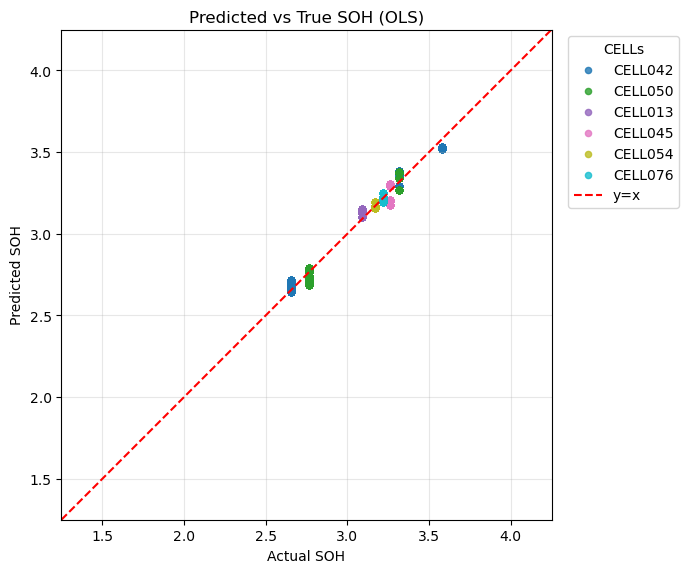

In [151]:
df_lr['_pred_OLS'] = ols_model.predict(X_lr_sm)

plt.figure(figsize=(7, 6))
# Use alternative color maps
unique_cells = df_lr['CELL'].unique()
cmap = cm.get_cmap('tab10', len(unique_cells))
COLOR_MAP = {cell: cmap(i) for i, cell in enumerate(unique_cells)}


# scatter by cell
for cell in unique_cells:  
    sub = df_lr[ df_lr["CELL"] == cell]
    plt.scatter(
        sub["SOH"], sub["_pred_OLS"],
        alpha=0.8, s=20, label=cell, color=COLOR_MAP[cell]
    )

# 45° reference line
plt.plot([1.25,4.25], [1.25,4.25], "r--",  label="y=x")

plt.xlabel("Actual SOH")
plt.ylabel("Predicted SOH")
plt.title("Predicted vs True SOH (OLS)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="CELLs")  # put legend outside
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.axis('square')
plt.xlim(1.25, 4.25)
plt.ylim(1.25, 4.25)
plt.show()

In [152]:
def standardize_predictors(df, scaler_stats):
    """
    Given synthetic df with columns R0, R1, R2, R3,
    return standardized predictors R0_z, ..., R3_z
    using the TRAINING means and stds.
    """
    df_z = df.copy()
    
    for col in ["R0", "R1", "R2", "R3"]:
        mean, std = scaler_stats[col]
        df_z[f"{col}_z"] = (df_z[col] - mean) / std

    return df_z

Calculate MAPE:

In [153]:
y_true = df_lr["SOH"].values
y_pred = df_lr["_pred_OLS"].values

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
print("All Cells MAPE: {:.3f}%".format(mape))
# R2, MAE, RMSE:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"R2: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# Calculate MAPE per cell
print("===============================")
mape_per_cell = (
    df_lr.groupby("CELL")
    .apply(lambda g: np.mean(np.abs((g["SOH"] - g["_pred_OLS"]) / g["SOH"])) * 100)
)

print(mape_per_cell)

All Cells MAPE: 1.072%
R2: 0.9834, MAE: 0.0327, RMSE: 0.0387
CELL
CELL013    1.264820
CELL042    1.130278
CELL045    1.517731
CELL050    1.161401
CELL054    0.493950
CELL076    0.422688
dtype: float64


C:\Users\liuha\AppData\Local\Temp\ipykernel_104496\3520997365.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.mean(np.abs((g["SOH"] - g["_pred_OLS"]) / g["SOH"])) * 100)


# Compute per-cell ECM Params mean & covariance; and average

In [107]:
ECM_COLS = ['R0', 'R1', 'R2', 'R3', 'C1', 'C2', 'C3', 'n1', 'n2', 'n3','Aw']

def compute_mean_cov(df_ref, log_space=True):
    """
    Compute per-cell means and covariances of ECM parameters, optionally in log-space
    
    Returns:
        - averaged mean and averaged covariance
        - per-cell dictionaries:
                mean_dict[cell] = mu_c
                cov_dict[cell] = Sigma_c
    """
    cell_ids = df_ref['CELL'].unique()
    
    # store per-cell mean and cov in dicts
    mean_dict = {}
    cov_dict = {}

    mus = []
    covs = []
    
    for cell in cell_ids:
        df_cell = df_ref[df_ref['CELL'] == cell]
        if df_cell.shape[0] < 2:
            # Can't compute covariance with < 2 points; skip
            print(f"Skipping cell {cell} with insufficient data points ({df_cell.shape[0]})")
            continue
        
        theta = df_cell[ECM_COLS].values.astype(float)
        
        if log_space:
            # log-transform R0..R3, C1..C3, Aw; keep n1..n3 unchanged
            theta_log = theta.copy()
            pos_idx = [ECM_COLS.index(c) for c in ['R0','R1','R2','R3','C1','C2','C3','Aw']]
            theta_log[:, pos_idx] = np.log(theta_log[:, pos_idx])
            X = theta_log
        else:
            X = theta
        
        mu_c = X.mean(axis=0)
        # Note: rowvar=False => columns are variables
        Sigma_c = np.cov(X, rowvar=False)
        
        # Store in dicts
        mean_dict[cell] = mu_c
        cov_dict[cell] = Sigma_c

        mus.append(mu_c)
        covs.append(Sigma_c)
    
    mus = np.array(mus)
    covs = np.array(covs)
    
    # Average mean and covariance over cells
    mu_theta = mus.mean(axis=0)
    Sigma_theta = covs.mean(axis=0)
    
    return  mu_theta, Sigma_theta, mean_dict, cov_dict


In [108]:
# Example:
mu_dind, Sigma_dind, mean_dict_dind, cov_dict_dind = compute_mean_cov(df_dind, log_space=True)

print("Averaged mean size:", mu_dind.shape)
print("Averaged covariance shape:", Sigma_dind.shape)
# print(mu_dind)
# print(Sigma_dind)

print("Per-cell means available:")
for cell, mu in mean_dict_dind.items():
    print(cell, mu.shape)


Averaged mean size: (11,)
Averaged covariance shape: (11, 11)
Per-cell means available:
CELL042 (11,)
CELL050 (11,)
CELL013 (11,)
CELL045 (11,)
CELL054 (11,)
CELL076 (11,)


In [109]:
# Example [OOD]:
mu_dood, Sigma_dood, mean_dict_dood, cov_dict_dood = compute_mean_cov(df_dood, log_space=True)

print("Averaged mean size:", mu_dood.shape)
print("Averaged covariance shape:", Sigma_dood.shape)
# print(mu_dind)
# print(Sigma_dind)

print("Per-cell means available:")
for cell, mu in mean_dict_dood.items():
    print(cell, mu.shape)

Averaged mean size: (11,)
Averaged covariance shape: (11, 11)
Per-cell means available:
CELL042 (11,)
CELL050 (11,)
CELL090 (11,)
CELL013 (11,)
CELL045 (11,)
CELL054 (11,)
CELL076 (11,)
CELL096 (11,)


# Sampling Synthetic ECM Parameter Vectors

In [ ]:

# Helper function: compute taus
def compute_tau(theta, ECM_COLS):
    """
    Compute tau1, tau2, tau3 from ECM parameters (Assume ECM with series RC components (R1||C1) + (R2||C2) + (R3||C3))
    tau_k = (R_k * C_k)^(1 / n_k)

    Parameters
    ----------
    theta : np.ndarray
        2D array of shape (N_samples, len(ECM_COLS))
    ECM_COLS : list[str]
        List of ECM column names in order used by theta.

    Returns
    -------
    tau1, tau2, tau3 : np.ndarray
        Arrays of tau values (length = N_valid_samples)
    """
    # column indices
    i_R1 = ECM_COLS.index('R1')
    i_R2 = ECM_COLS.index('R2')
    i_R3 = ECM_COLS.index('R3')
    i_C1 = ECM_COLS.index('C1')
    i_C2 = ECM_COLS.index('C2')
    i_C3 = ECM_COLS.index('C3')
    i_n1 = ECM_COLS.index('n1')
    i_n2 = ECM_COLS.index('n2')
    i_n3 = ECM_COLS.index('n3')

    # extract arrays
    R1 = theta[:, i_R1]
    R2 = theta[:, i_R2]
    R3 = theta[:, i_R3]
    C1 = theta[:, i_C1]
    C2 = theta[:, i_C2]
    C3 = theta[:, i_C3]
    n1 = theta[:, i_n1]
    n2 = theta[:, i_n2]
    n3 = theta[:, i_n3]

    # compute taus
    tau1 = (R1 * C1)**(1.0 / n1)
    tau2 = (R2 * C2)**(1.0 / n2)
    tau3 = (R3 * C3)**(1.0 / n3)

    return tau1, tau2, tau3



def sample_ecm_parameters(mu_theta, Sigma_theta, n_samples=1000,
                          log_space=True,
                          clamp_n=(0.5, 1.0),
                          min_val=1e-6, seed=123):
    """
    Sample synthetic ECM parameter vectors using the baseline model. Apply clampping on n and minimal value, ordered taus criteria
    to keep valid samples
    
    Returns: DataFrame with columns ECM_COLS
    """
    rng = np.random.default_rng(seed = seed)
    dim = len(mu_theta)
    samples = rng.multivariate_normal(mu_theta, Sigma_theta, size=n_samples)
    
    if log_space:
        # If previous parameters mu are calculated in log-space
        # Undo log-transform:
        theta = samples.copy()
        pos_idx = [ECM_COLS.index(c) for c in ['R0','R1','R2','R3',
                                               'C1','C2','C3','Aw']]
        theta[:, pos_idx] = np.exp(theta[:, pos_idx])
    else:
        theta = samples
    
    # Clamp n's
    if clamp_n is not None:
        n_min, n_max = clamp_n
        n_idx = [ECM_COLS.index(c) for c in ['n1','n2','n3']]
        theta[:, n_idx] = np.clip(theta[:, n_idx], n_min, n_max)
    
    # Drop invalid samples (any parameter < min_val)
    valid_mask = (theta > min_val).all(axis=1)
    theta = theta[valid_mask]
    print(f"Drop invalid small samples, {len(theta)} samples left.")

    if theta.shape[0] == 0:
        return pd.DataFrame(columns=ECM_COLS + (['tau1','tau2','tau3']))
    
    # Enforce taus order: tau1 <= tau2 <= tau3
    tau1, tau2, tau3 = compute_tau(theta, ECM_COLS)
    tau_mask = (tau1 < tau2) & (tau2 < tau3)
    theta = theta[tau_mask]
    tau1 = tau1[tau_mask]
    tau2 = tau2[tau_mask]
    tau3 = tau3[tau_mask]
    print(f"Enforce taus non-decreasing order, {len(theta)} samples left.")

    df_theta = pd.DataFrame(theta, columns=ECM_COLS)

    df_theta['tau1'] = tau1
    df_theta['tau2'] = tau2
    df_theta['tau3'] = tau3
    

    return df_theta

In [111]:
print("===== Synthetic InD Data =====")
df_theta_sim_ind = sample_ecm_parameters(
    mu_dind, Sigma_dind,
    n_samples=1000
)

print("===== Synthetic OoD Data =====")
df_theta_sim_ood = sample_ecm_parameters(
    mu_dood, Sigma_dood,
    n_samples=1000
)



===== Synthetic InD Data =====
Drop invalid small samples, 1000 samples left.
Enforce taus non-decreasing order, 1000 samples left.
===== Synthetic OoD Data =====
Drop invalid small samples, 1000 samples left.
Enforce taus non-decreasing order, 1000 samples left.


per-cell ind data:

In [177]:
cells = list(mean_dict_dind.keys())

per_cell_sim_ind= {}
for cell in cells:
    print("Generating synthetic parameters for cell:", cell)
    
    # InD
    df_theta_cell_ind = sample_ecm_parameters(
        mean_dict_dind[cell],
        cov_dict_dind[cell],
        n_samples=100
    )
    per_cell_sim_ind[cell] = df_theta_cell_ind

    

Generating synthetic parameters for cell: CELL042
Drop invalid small samples, 100 samples left.
Enforce taus non-decreasing order, 100 samples left.
Generating synthetic parameters for cell: CELL050
Drop invalid small samples, 100 samples left.
Enforce taus non-decreasing order, 100 samples left.
Generating synthetic parameters for cell: CELL013
Drop invalid small samples, 100 samples left.
Enforce taus non-decreasing order, 100 samples left.
Generating synthetic parameters for cell: CELL045
Drop invalid small samples, 100 samples left.
Enforce taus non-decreasing order, 100 samples left.
Generating synthetic parameters for cell: CELL054
Drop invalid small samples, 100 samples left.
Enforce taus non-decreasing order, 100 samples left.
Generating synthetic parameters for cell: CELL076
Drop invalid small samples, 100 samples left.
Enforce taus non-decreasing order, 100 samples left.


In [183]:
print(per_cell_sim_ind["CELL013"]["n3"].min())
print(per_cell_sim_ind["CELL013"]["n3"].max())
print(df_dind[df_dind['CELL'] == "CELL013"]['n3'].min())
print(df_dind[df_dind['CELL'] == "CELL013"]['n3'].max())


0.799999999999994
0.800000000000014
0.8000000000000002
0.8000000000000002


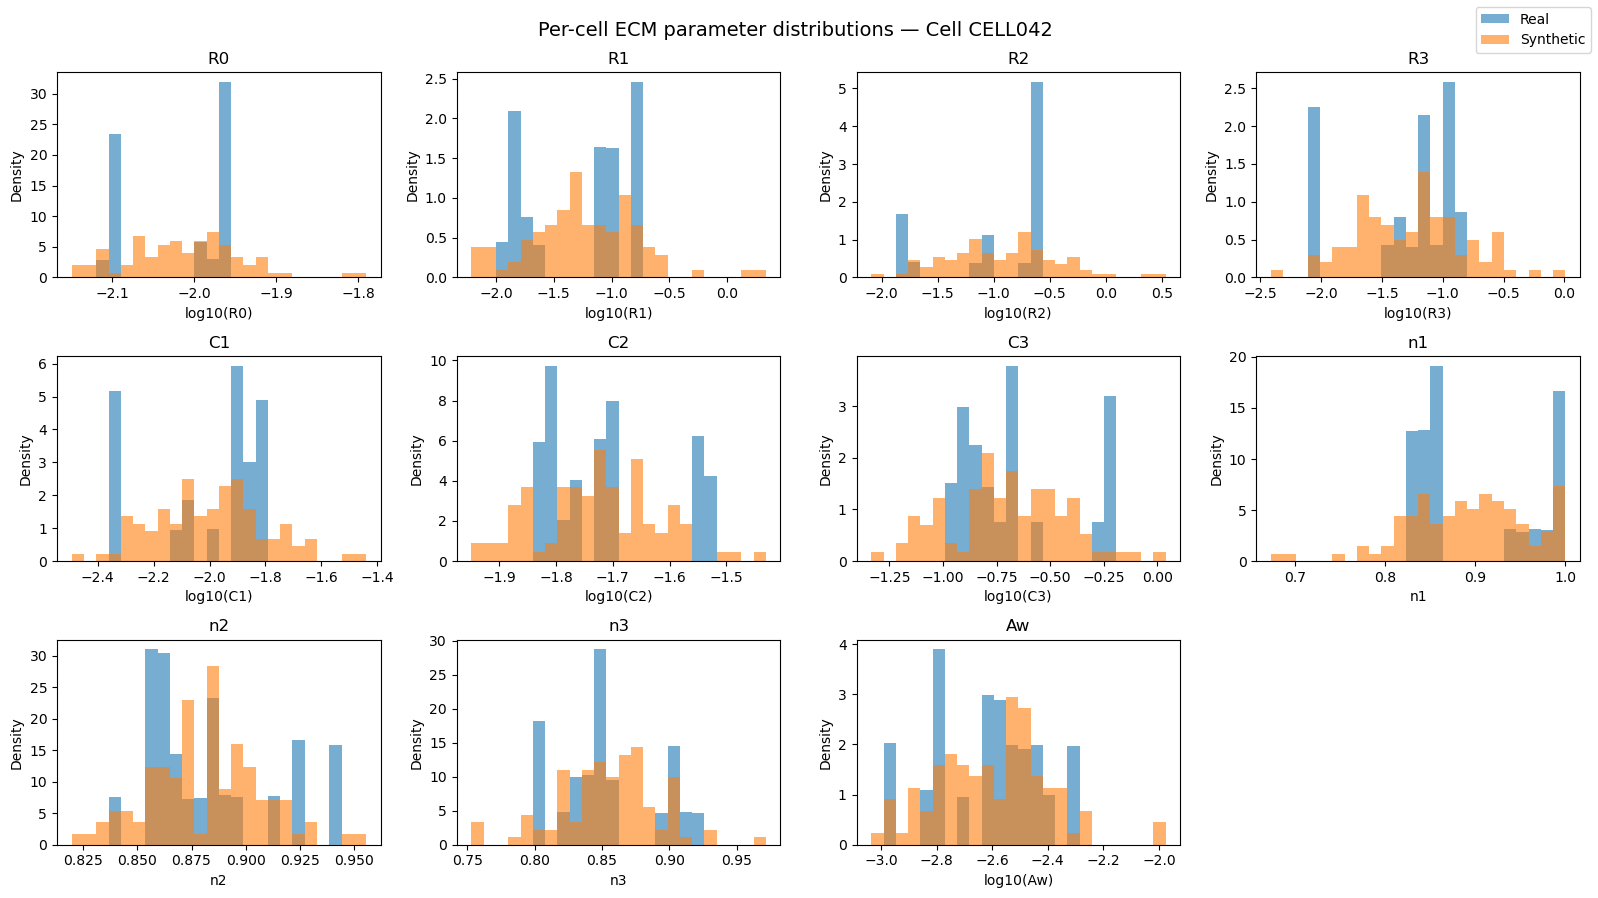

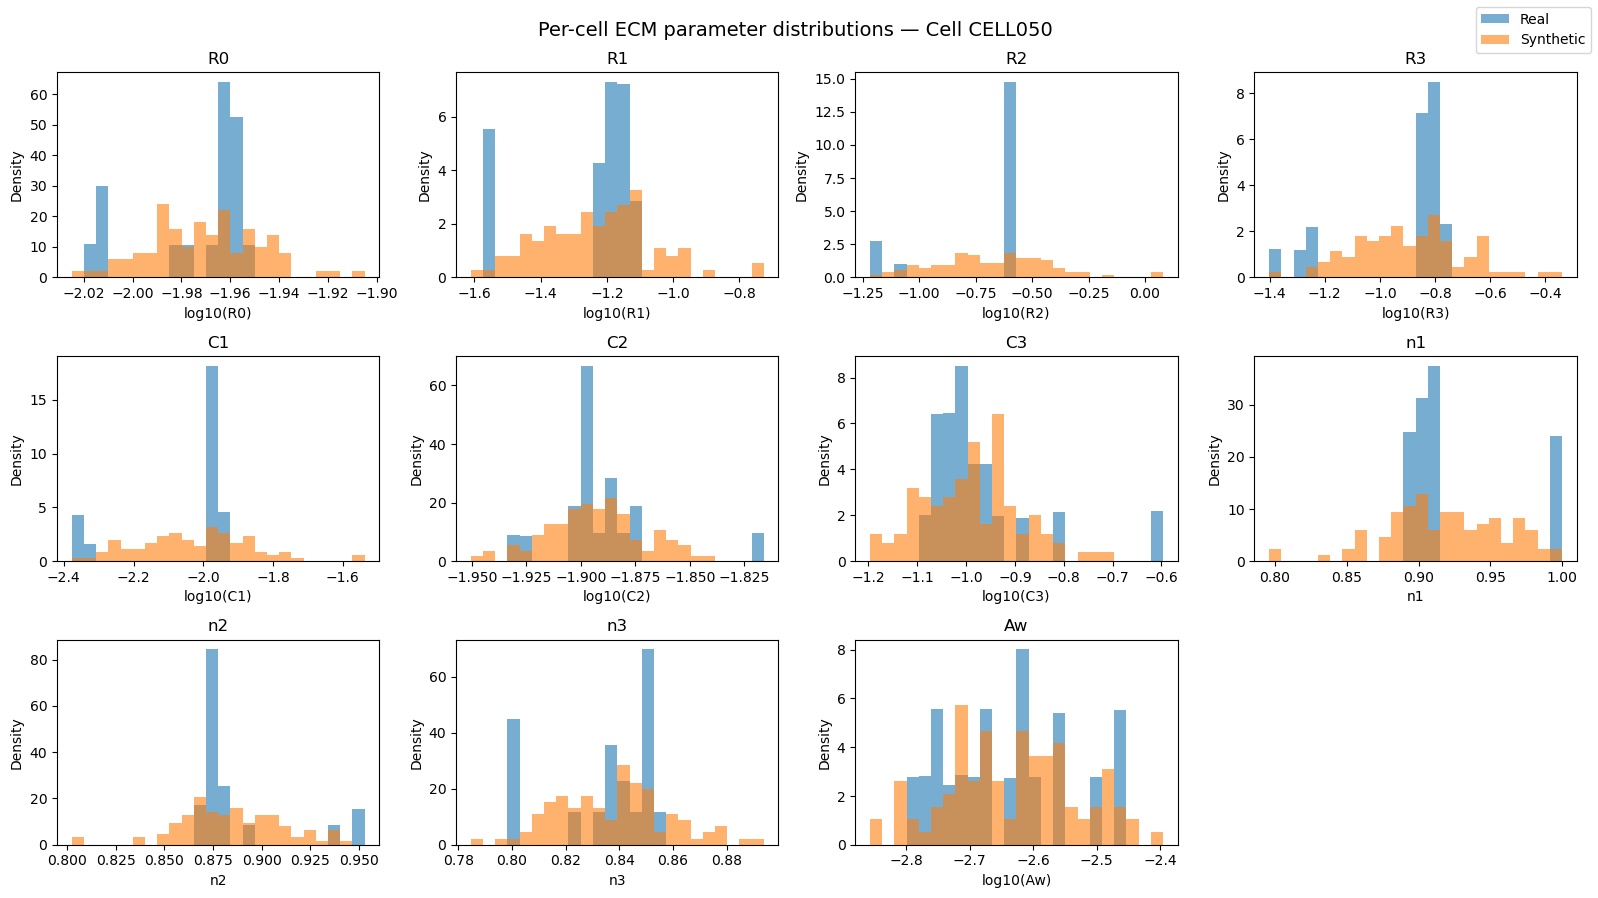

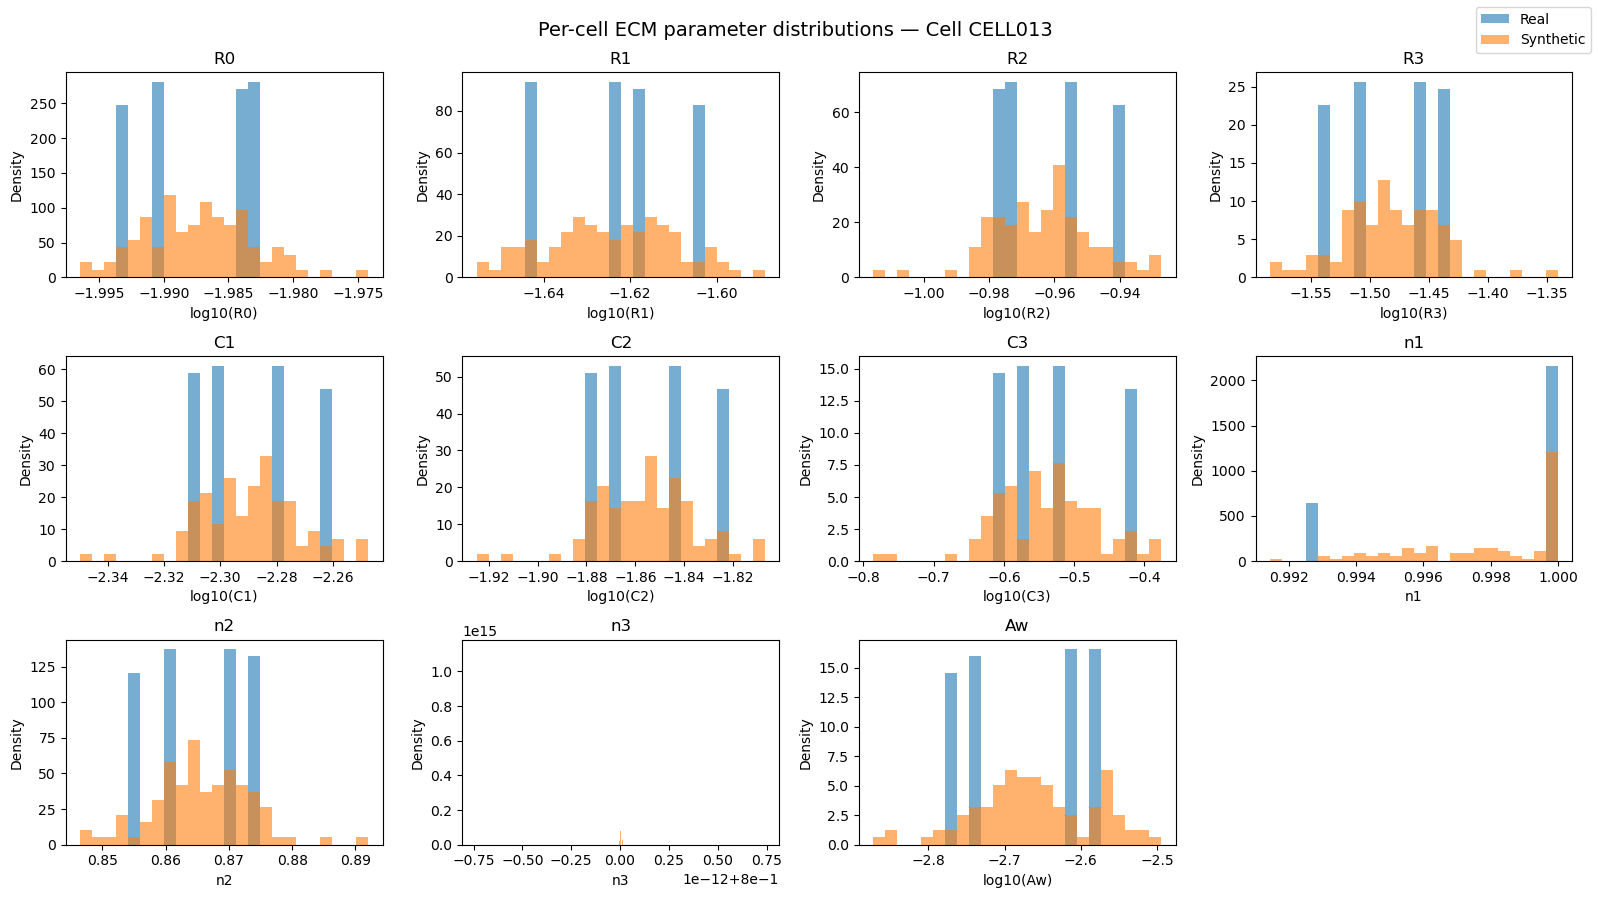

c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\numpy\lib\_histograms_impl.py:895: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
c:\Users\liuha\miniconda3\envs\EIS\Lib\site-packages\numpy\lib\_histograms_impl.py:895: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


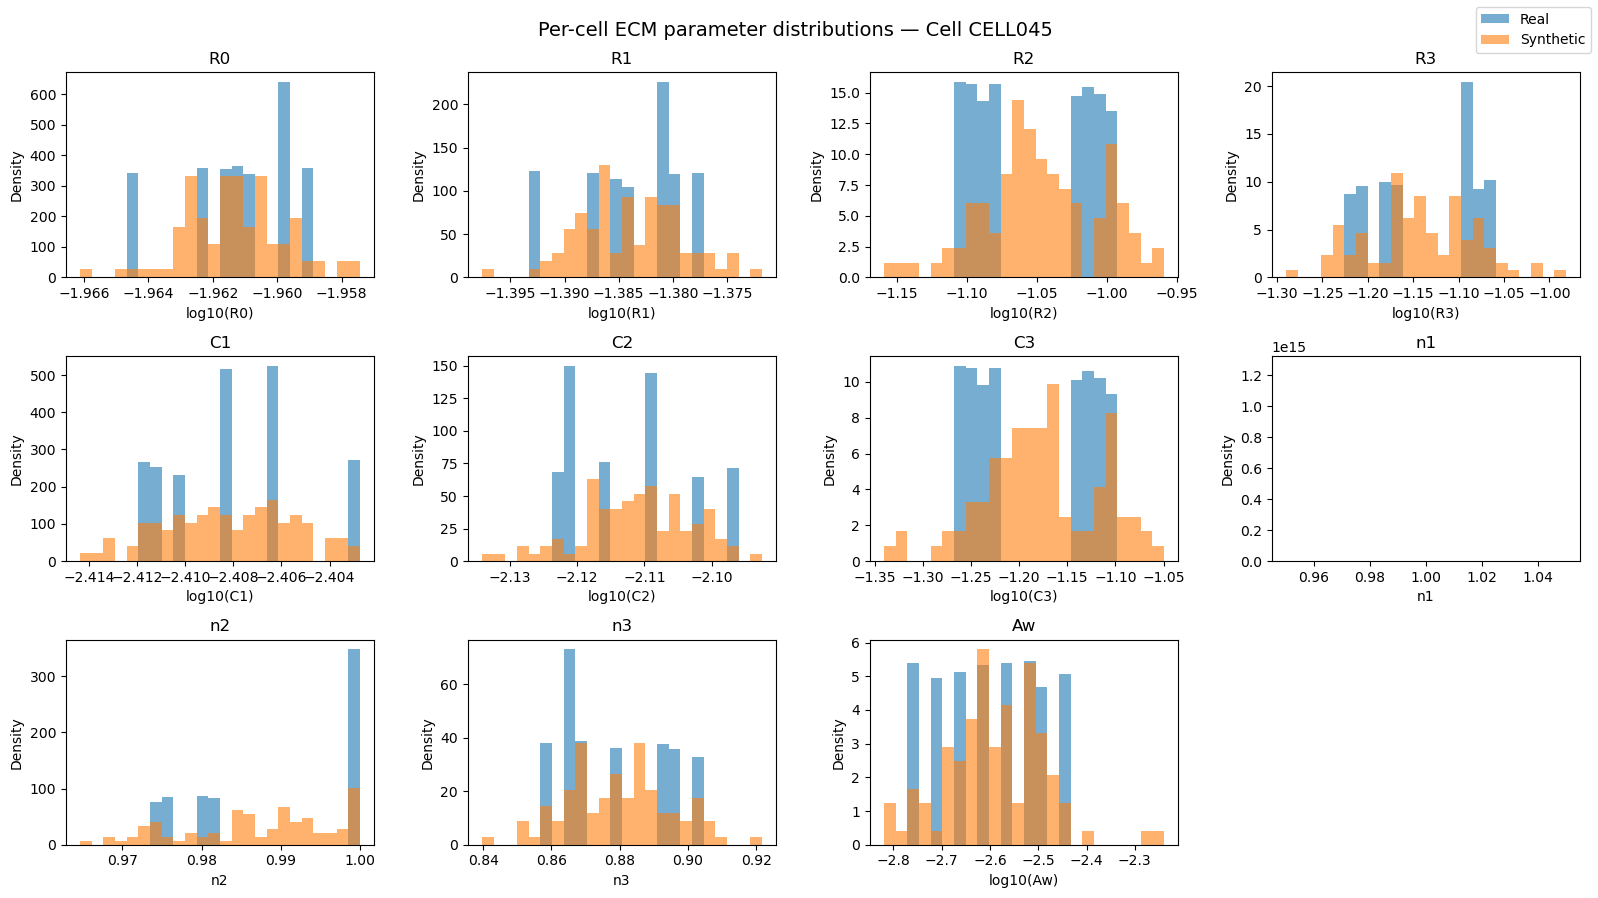

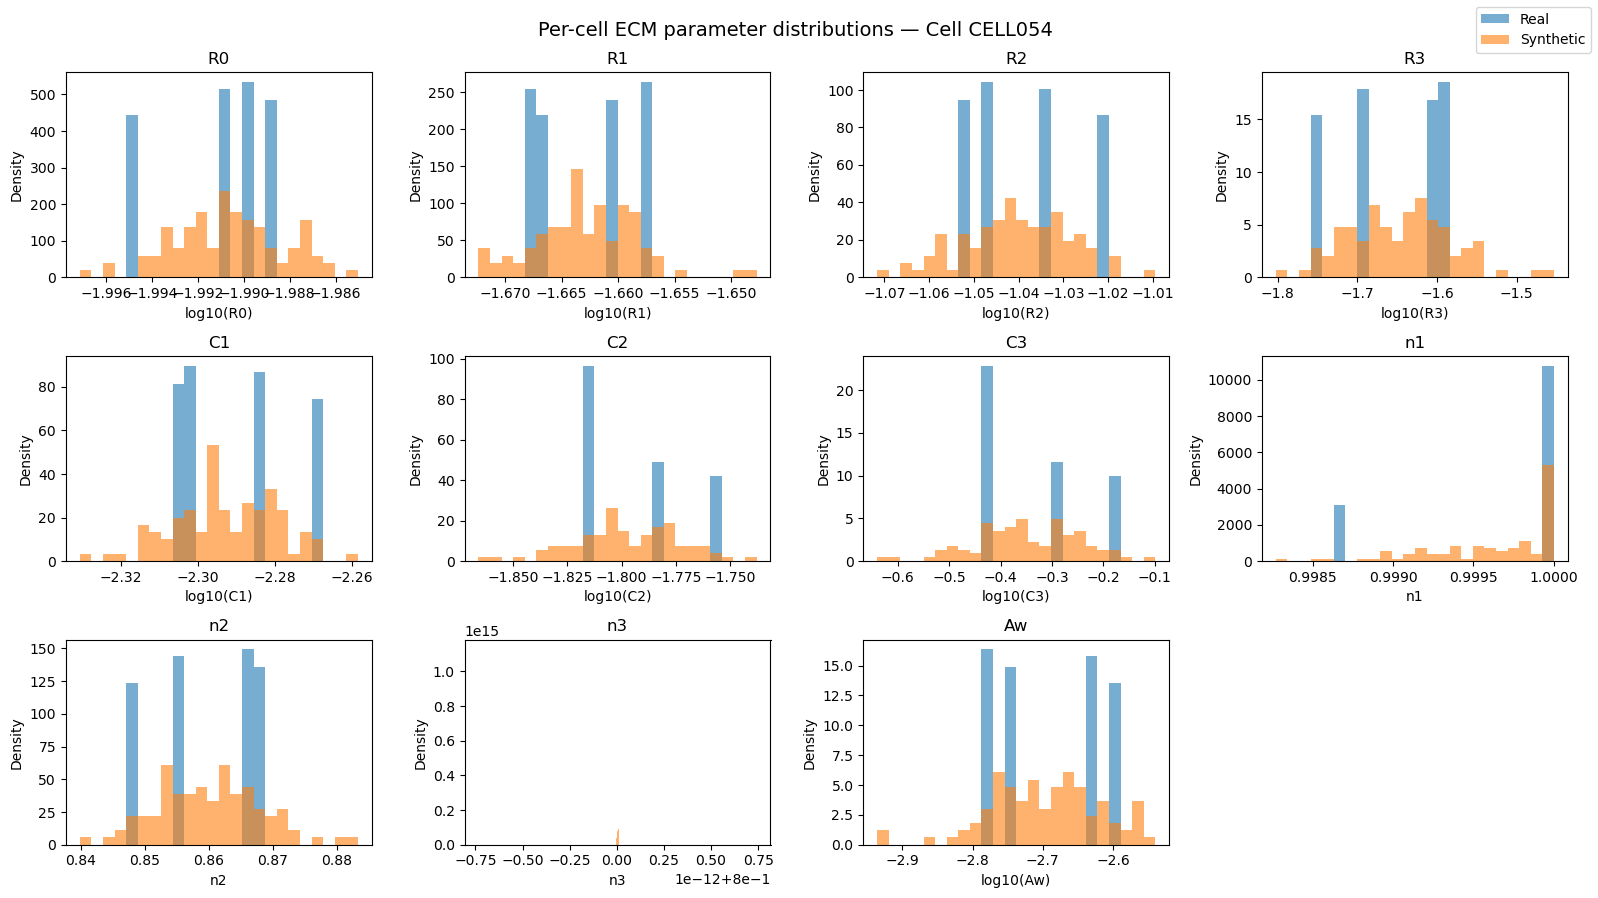

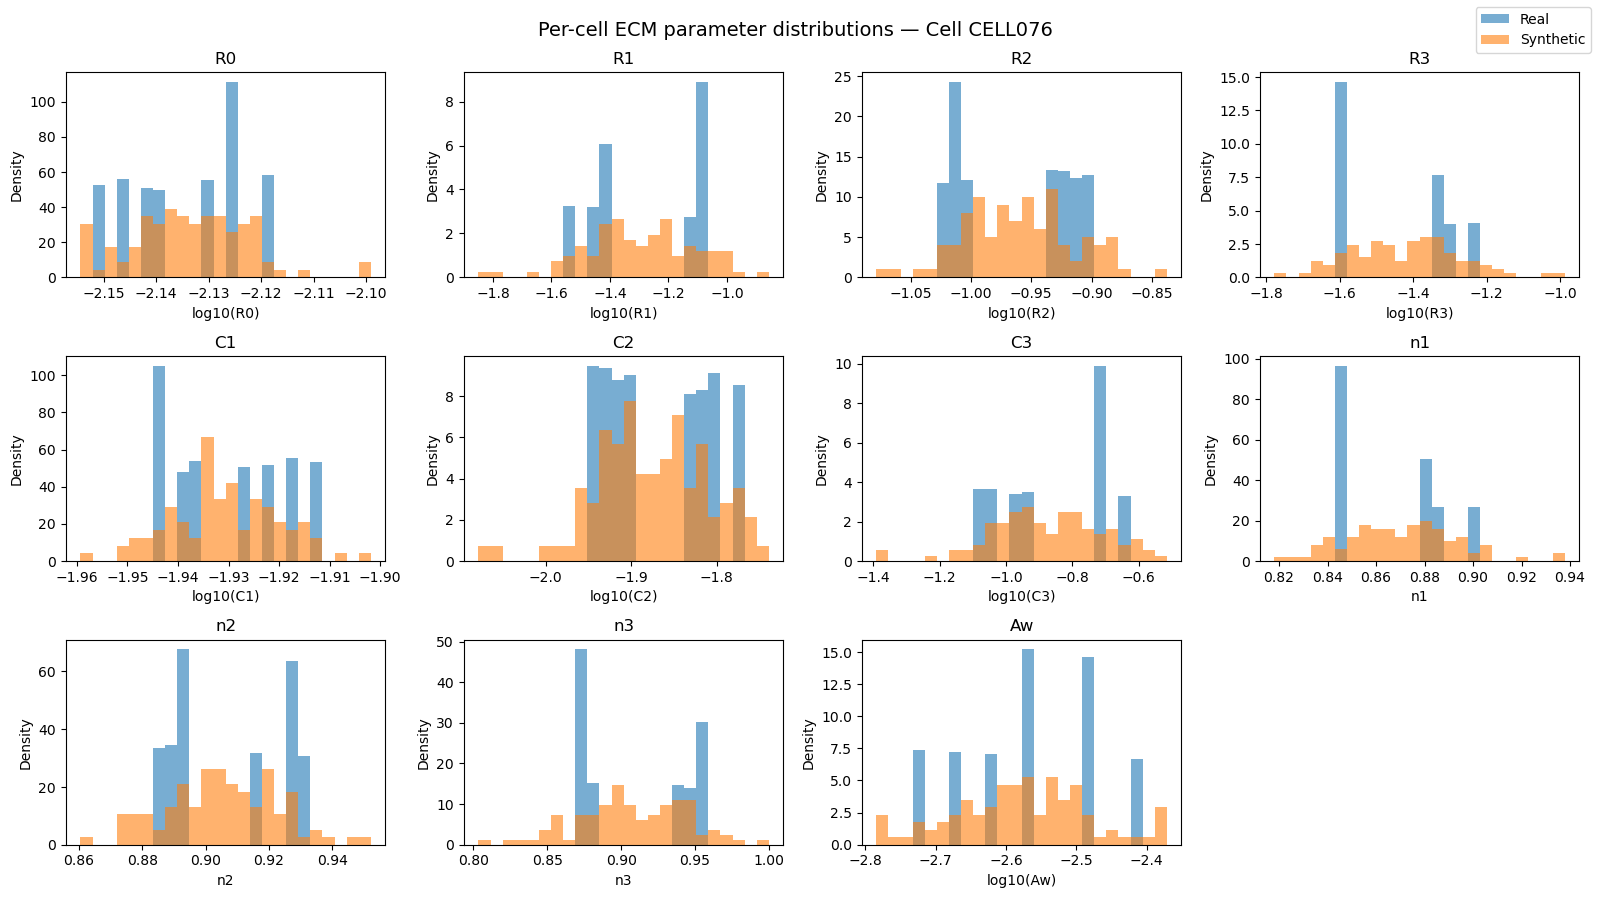

In [178]:
ECM_COLS = ['R0','R1','R2','R3',
            'C1','C2','C3',
            'n1','n2','n3',
            'Aw']

# Parameters where a log-scale view is more meaningful
LOG_PARAMS = ['R0','R1','R2','R3','C1','C2','C3','Aw']

cells = list(mean_dict_dind.keys())  # or df_dind['CELL'].unique()

for cell in cells:
    df_real = df_dind[df_dind['CELL'] == cell]
    df_syn  = per_cell_sim_ind[cell]   # synthetic ECM for this cell

    # Skip if no synthetic data
    if df_syn.empty or df_real.empty:
        continue

    n_params = len(ECM_COLS)
    ncols = 4
    nrows = int(np.ceil(n_params / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
    axes = axes.flatten()

    for i, param in enumerate(ECM_COLS):
        ax = axes[i]

        real_vals = df_real[param].dropna().values
        syn_vals  = df_syn[param].dropna().values

        if len(real_vals) == 0 or len(syn_vals) == 0:
            ax.set_visible(False)
            continue

        # Choose domain (log10 if param is in LOG_PARAMS)
        if param in LOG_PARAMS:
            real_plot = np.log10(real_vals)
            syn_plot  = np.log10(syn_vals)
            xlabel = f"log10({param})"
        else:
            real_plot = real_vals
            syn_plot  = syn_vals
            xlabel = param

        # Common bins
        vmin = min(real_plot.min(), syn_plot.min())
        vmax = max(real_plot.max(), syn_plot.max())
        bins = np.linspace(vmin, vmax, 25)

        ax.hist(real_plot, bins=bins, alpha=0.6, density=True, label='Real')
        ax.hist(syn_plot,  bins=bins, alpha=0.6, density=True, label='Synthetic')

        ax.set_title(param)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Density")

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Per-cell ECM parameter distributions — Cell {cell}", fontsize=14)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()


# Generate Synthetic SOH from LR model

In [ ]:
def compute_synthetic_soh(df_theta, ols_model, sigma_eps=None, seed=123):
    """
    Compute synthetic SOH using a fitted statsmodels OLS model.

    Parameters
    ----------
    df_theta : pd.DataFrame
        Must contain at least columns: 'R0','R1','R2','R3'.
    ols_model : statsmodels.regression.linear_model.RegressionResultsWrapper
        Fitted OLS model (SOH ~ R0 + R1 + R2 + R3).
    sigma_eps : float or None
        Residual std. If None, uses sqrt(ols_model.mse_resid).
        If > 0, Gaussian noise with this std will be added to predictions.

    Returns
    -------
    soh : np.ndarray
        Synthetic SOH with noise (if sigma_eps > 0) or equal to soh_hat.
    soh_hat : np.ndarray
        Deterministic OLS predictions (no noise).
    """
    rng = np.random.default_rng(seed = seed)
    
    # Design matrix for prediction: same structure as training
    df_theta_std = standardize_predictors(df_theta, scaler_stats)
    X = df_theta_std[['R0_z', 'R1_z', 'R2_z', 'R3_z']]
    X_sm = sm.add_constant(X, has_constant='add')

    
    soh_hat = ols_model.predict(X_sm)

    # Residual std: from model if not provided
    if sigma_eps is None:
        sigma_eps = np.sqrt(ols_model.mse_resid)

    # Add noise if sigma_eps > 0
    if sigma_eps is not None and sigma_eps > 0:
        noise = rng.normal(0.0, sigma_eps, size=len(soh_hat))
        soh = soh_hat + noise
    else:
        soh = soh_hat

    return soh, soh_hat

In [114]:
# Example:
soh_sim, soh_hat_sim = compute_synthetic_soh(
    df_theta_sim_ind,
    ols_model=ols_model,        # statsmodels OLS object
    sigma_eps=None              # or set a specific value
)

df_theta_sim_ind['SOH_sim'] = soh_sim

df_theta_sim_ind[['R0', 'R1', 'R2', 'R3', 'SOH_sim']].head()



,R0,R1,R2,R3,SOH_sim
0,0.010289,0.059646,0.190076,0.068362,2.833176
1,0.010015,0.050602,0.267661,0.109937,2.673237
2,0.008653,0.015329,0.051762,0.026229,3.448684
3,0.010872,0.095864,0.385367,0.115820,2.198774
4,0.010413,0.061583,0.165672,0.059334,2.972691


In [115]:
# Example:
soh_sim_ood, soh_hat_sim = compute_synthetic_soh(
    df_theta_sim_ood,
    ols_model=ols_model,        # statsmodels OLS object
    sigma_eps=None              # or set a specific value
)

df_theta_sim_ood['SOH_sim'] = soh_sim_ood

df_theta_sim_ood[['R0', 'R1', 'R2', 'R3', 'SOH_sim']].head()

,R0,R1,R2,R3,SOH_sim
0,0.008862,0.110168,0.218945,0.039675,2.676106
1,0.008984,0.134807,0.427270,0.098777,2.023124
2,0.008709,0.015414,0.071569,0.050565,3.422644
3,0.008120,0.224668,0.462075,0.050366,1.769241
4,0.009059,0.075850,0.173662,0.035462,2.932605


In [161]:
print(df_theta_sim_ind["SOH_sim"].min())
print(df_theta_sim_ind["SOH_sim"].max())

# print statistics for OOD synthetic data
print(f"  Mean: {df_theta_sim_ind["SOH_sim"].mean():.3f}, Std: {df_theta_sim_ind["SOH_sim"].std(ddof=0):.3f}, Min: {df_theta_sim_ind["SOH_sim"].min():.3f}, Max: {df_theta_sim_ind["SOH_sim"].max():.3f}")

print("OOD:")
print(df_theta_sim_ood["SOH_sim"].min())
print(df_theta_sim_ood["SOH_sim"].max())
print(f"  Mean: {df_theta_sim_ood["SOH_sim"].mean():.3f}, Std: {df_theta_sim_ood["SOH_sim"].std(ddof=0):.3f}, Min: {df_theta_sim_ood["SOH_sim"].min():.3f}, Max: {df_theta_sim_ood["SOH_sim"].max():.3f}")


1.4974603489054215
3.5569735856999314
  Mean: 3.094, Std: 0.263, Min: 1.497, Max: 3.557
OOD:
0.2533525055775311
3.5362376064847894
  Mean: 2.978, Std: 0.430, Min: 0.253, Max: 3.536


Generalized Samples Visualization:

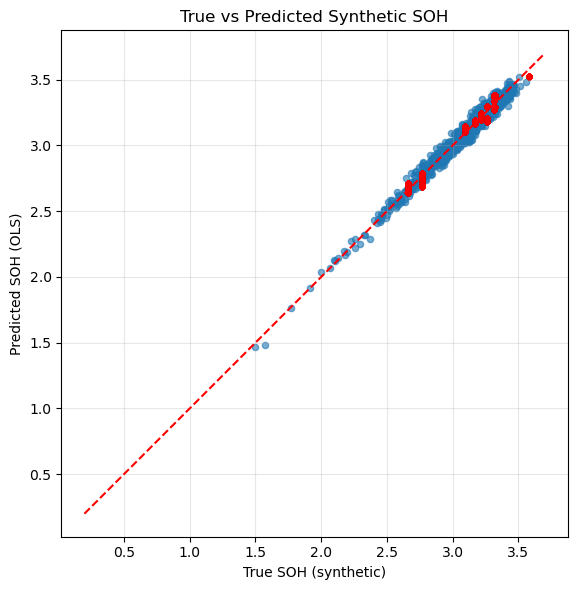

MAPE on synthetic D'InD: 1.009%


In [171]:
df_sim_std = standardize_predictors(df_theta_sim_ind, scaler_stats)

# Build standardized design matrix for synthetic data
X_sim_z = df_sim_std[['R0_z', 'R1_z', 'R2_z', 'R3_z']]
X_sim_z_sm = sm.add_constant(X_sim_z)

# Predict SOH
df_sim_std["SOH_pred_OLS"] = ols_model.predict(X_sim_z_sm)
plt.figure(figsize=(7,6))

plt.scatter(
    df_sim_std["SOH_sim"],
    df_sim_std["SOH_pred_OLS"],
    s=20, alpha=0.6
)
plt.scatter(
    df_lr["SOH"],
    df_lr["_pred_OLS"],
    s=10, alpha=0.1, color='red', label="Training data"
)

# 45° line
low = 0.2
high = 3.7
plt.plot([low, high], [low, high], 'r--')

plt.xlabel("True SOH (synthetic)")
plt.ylabel("Predicted SOH (OLS)")
plt.title("True vs Predicted Synthetic SOH")
plt.grid(alpha=0.3)
plt.xlim(0.2, 3.7)
plt.axis("square")

plt.tight_layout()
plt.show()


y_true_sim = df_sim_std['SOH_sim'].values
y_pred_sim = df_sim_std['SOH_pred_OLS'].values

mape_sim = np.mean(np.abs((y_true_sim - y_pred_sim) / y_true_sim)) * 100
print(f"MAPE on synthetic D'InD: {mape_sim:.3f}%")

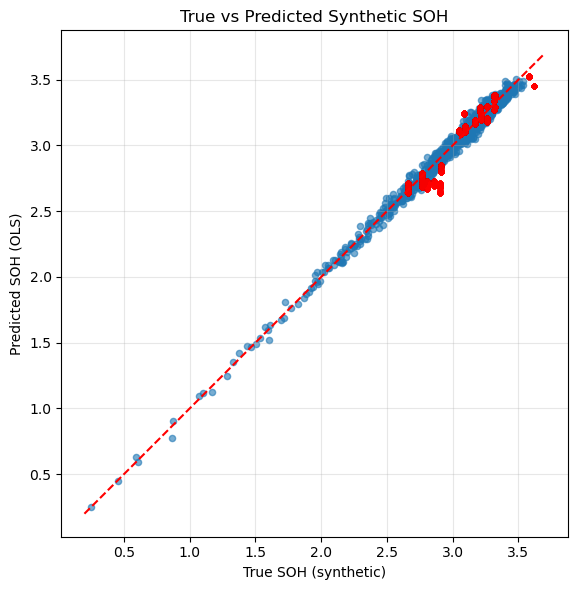

MAPE on synthetic D'ooD: 1.076%


In [172]:
# ood example
df_sim_stdood = standardize_predictors(df_theta_sim_ood, scaler_stats)
df_ood_std = standardize_predictors(df_dood, scaler_stats)

# Build standardized design matrix for synthetic data
X_sim_z = df_sim_stdood[['R0_z', 'R1_z', 'R2_z', 'R3_z']]
X_sim_z_sm = sm.add_constant(X_sim_z)

X_ood_z = df_ood_std[['R0_z', 'R1_z', 'R2_z', 'R3_z']]
X_ood_z_sm = sm.add_constant(X_ood_z)

# Predict SOH
df_sim_stdood["SOH_pred_OLS"] = ols_model.predict(X_sim_z_sm)
df_ood_std["_pred_OLS"] = ols_model.predict(X_ood_z_sm)

plt.figure(figsize=(7,6))

plt.scatter(
    df_sim_stdood["SOH_sim"],
    df_sim_stdood["SOH_pred_OLS"],
    s=20, alpha=0.6
)
plt.scatter(
    df_ood_std["SOH"],
    df_ood_std["_pred_OLS"],
    s=10, alpha=0.1, color='red', label="OOD data"
)

# 45° line
low = 0.2
high = 3.7
plt.plot([low, high], [low, high], 'r--')

plt.xlabel("True SOH (synthetic)")
plt.ylabel("Predicted SOH (OLS)")
plt.title("True vs Predicted Synthetic SOH")
plt.grid(alpha=0.3)
plt.xlim(0.2, 3.7)
plt.axis("square")
plt.tight_layout()
plt.show()


y_true_sim = df_sim_stdood['SOH_sim'].values
y_pred_sim = df_sim_stdood['SOH_pred_OLS'].values

mape_sim = np.mean(np.abs((y_true_sim - y_pred_sim) / y_true_sim)) * 100
print(f"MAPE on synthetic D'ooD: {mape_sim:.3f}%")

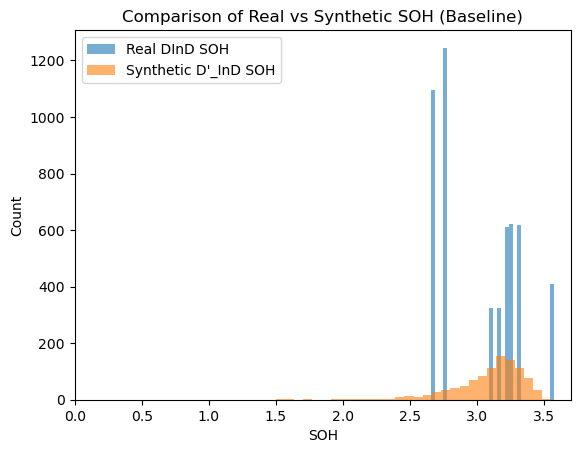

In [133]:
plt.figure()
plt.hist(df_dind['SOH'], bins=30, alpha=0.6, label='Real DInD SOH')
plt.hist(df_theta_sim_ind['SOH_sim'], bins=30, alpha=0.6, label='Synthetic D\'_InD SOH')
plt.xlabel('SOH')
plt.ylabel('Count')
plt.legend()
plt.title('Comparison of Real vs Synthetic SOH (Baseline)')
plt.xlim(0, 3.7)
plt.show()


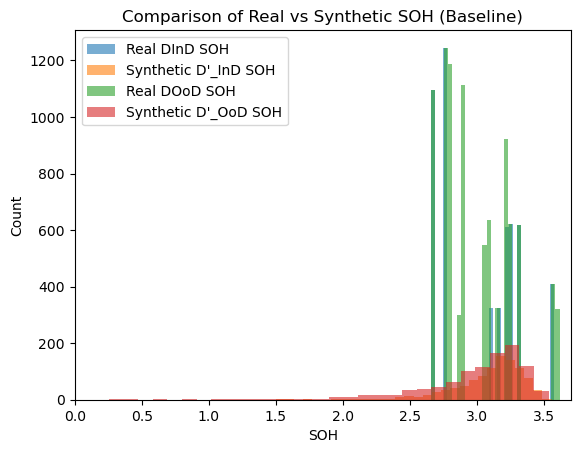

In [132]:

plt.figure()
plt.hist(df_dind['SOH'], bins=30, alpha=0.6, label='Real DInD SOH')
plt.hist(df_theta_sim_ind['SOH_sim'], bins=30, alpha=0.6, label='Synthetic D\'_InD SOH')
plt.hist(df_dood['SOH'], bins=30, alpha=0.6, label='Real DOoD SOH')
plt.hist(df_theta_sim_ood['SOH_sim'], bins=30, alpha=0.6, label='Synthetic D\'_OoD SOH')

plt.xlabel('SOH')
plt.ylabel('Count')
plt.legend()
plt.title('Comparison of Real vs Synthetic SOH (Baseline)')
plt.xlim(0, 3.7)
plt.show()

per-cell data:

In [137]:
cells = list(mean_dict_dind.keys())

for cell in cells:
    print("Generating synthetic SOH for cell:", cell)
    
    # InD
    soh_sim, _ = compute_synthetic_soh(
        per_cell_sim_ind[cell],
        ols_model=ols_model,
        sigma_eps=None
    )
    per_cell_sim_ind[cell]['SOH_sim'] = soh_sim


for cell in cells:
    print(f"{cell} synthetic SOH stats:")
    soh_values = per_cell_sim_ind[cell]['SOH_sim'].values
    print(f"  Mean: {soh_values.mean():.3f}, Std: {soh_values.std(ddof=0):.3f}, Min: {soh_values.min():.3f}, Max: {soh_values.max():.3f}")

Generating synthetic SOH for cell: CELL042
Generating synthetic SOH for cell: CELL050
Generating synthetic SOH for cell: CELL013
Generating synthetic SOH for cell: CELL045
Generating synthetic SOH for cell: CELL054
Generating synthetic SOH for cell: CELL076
CELL042 synthetic SOH stats:
  Mean: 2.720, Std: 1.543, Min: -8.414, Max: 3.618
CELL050 synthetic SOH stats:
  Mean: 2.787, Std: 0.539, Min: -0.176, Max: 3.406
CELL013 synthetic SOH stats:
  Mean: 3.135, Std: 0.038, Min: 3.030, Max: 3.271
CELL045 synthetic SOH stats:
  Mean: 3.245, Std: 0.060, Min: 3.054, Max: 3.436
CELL054 synthetic SOH stats:
  Mean: 3.185, Std: 0.037, Min: 3.077, Max: 3.314
CELL076 synthetic SOH stats:
  Mean: 3.225, Std: 0.036, Min: 3.121, Max: 3.324


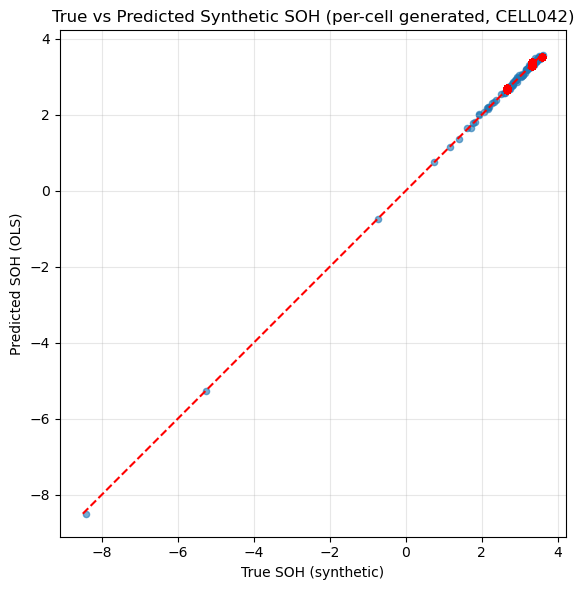

MAPE on synthetic D'InD: 1.002%


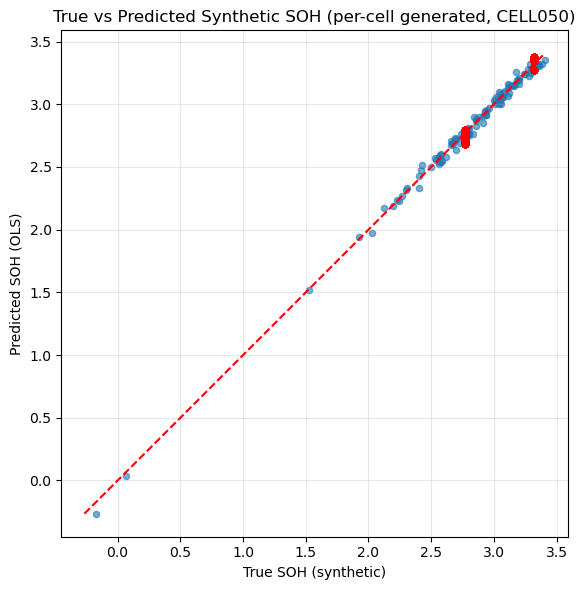

MAPE on synthetic D'InD: 1.933%


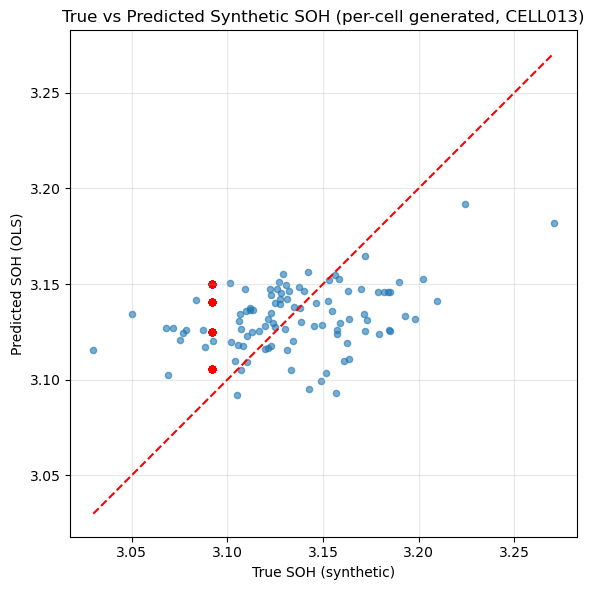

MAPE on synthetic D'InD: 0.892%


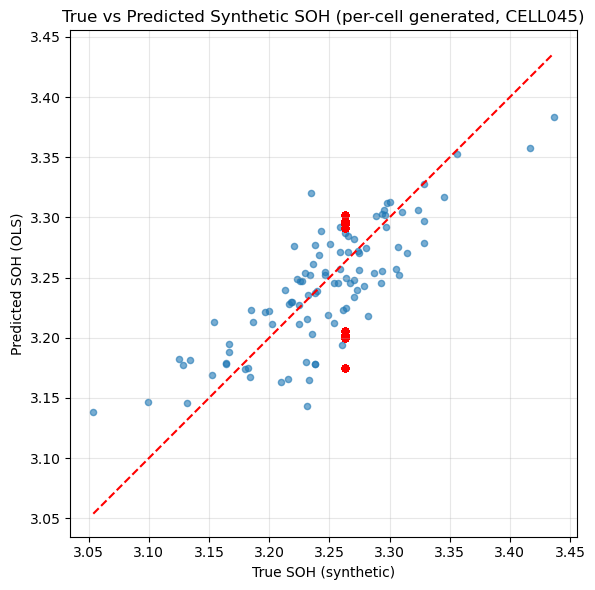

MAPE on synthetic D'InD: 0.865%


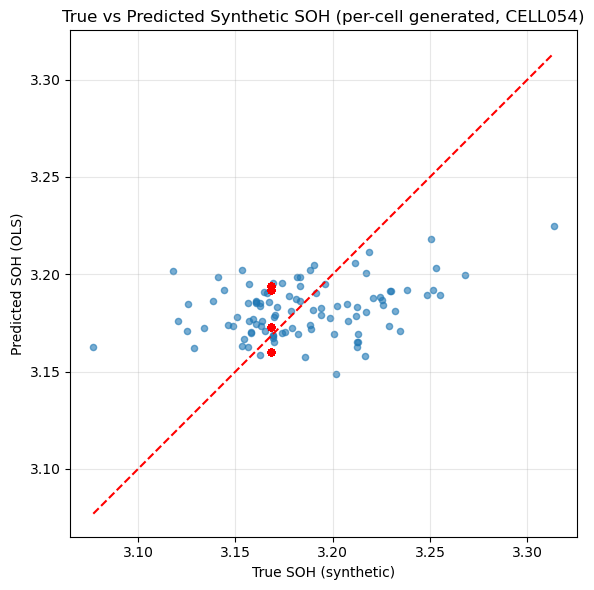

MAPE on synthetic D'InD: 0.878%


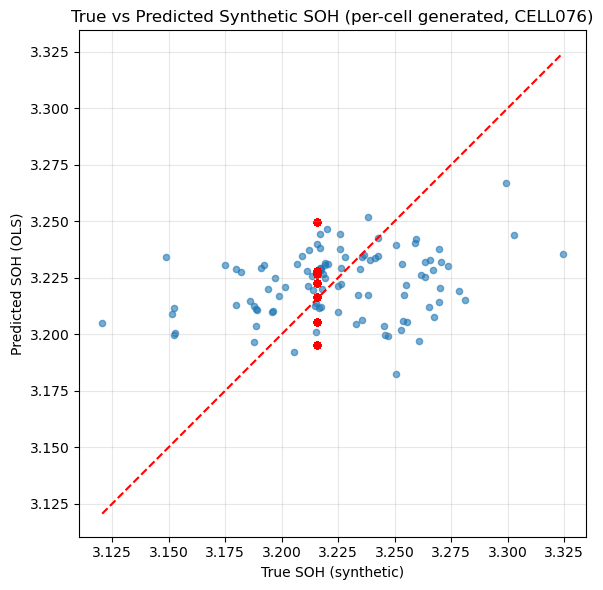

MAPE on synthetic D'InD: 0.868%


In [141]:
cells = list(mean_dict_dind.keys())

for cell in cells:
    df_sim_cell_std = standardize_predictors(per_cell_sim_ind[cell], scaler_stats)

    # Build standardized design matrix for synthetic data
    X_sim_z = df_sim_cell_std[['R0_z', 'R1_z', 'R2_z', 'R3_z']]
    X_sim_z_sm = sm.add_constant(X_sim_z)

    # Predict SOH
    df_sim_cell_std["SOH_pred_OLS"] = ols_model.predict(X_sim_z_sm)
    plt.figure(figsize=(7,6))

    plt.scatter(
        df_sim_cell_std["SOH_sim"],
        df_sim_cell_std["SOH_pred_OLS"],
        s=20, alpha=0.6
    )

    sub = df_lr[df_lr["CELL"] == cell]
    plt.scatter(
        sub["SOH"], sub["_pred_OLS"],
        alpha=0.8, s=20, label=cell, color="red"
    )

    # 45° line
    low = min(df_sim_cell_std["SOH_sim"].min(), df_sim_cell_std["SOH_pred_OLS"].min())
    high = max(df_sim_cell_std["SOH_sim"].max(), df_sim_cell_std["SOH_pred_OLS"].max())
    plt.plot([low, high], [low, high], 'r--')

    plt.xlabel("True SOH (synthetic)")
    plt.ylabel("Predicted SOH (OLS)")
    plt.title(f"True vs Predicted Synthetic SOH (per-cell generated, {cell})")
    plt.grid(alpha=0.3)
    plt.axis("square")
    plt.tight_layout()
    plt.show()


    y_true_sim = df_sim_cell_std['SOH_sim'].values
    y_pred_sim = df_sim_cell_std['SOH_pred_OLS'].values

    mape_sim = np.mean(np.abs((y_true_sim - y_pred_sim) / y_true_sim)) * 100
    print(f"MAPE on synthetic D'InD: {mape_sim:.3f}%")

# EIS Reconstruction

In [120]:
def warburg_impedance(Aw, omega):
    # Warburg: (Aw *sqrt(2)) / sqrt(j*omega)
    j = 1j
    return (Aw * np.sqrt(2)) / np.sqrt(j * omega)

def cpe_impedance(Q, n, omega):
    j = 1j
    return 1.0 / (Q * (j * omega)**n)

def parallel_impedance(Z1, Z2):
    return 1.0 / (1.0/Z1 + 1.0/Z2)

def ecm_impedance_C9(params, omega):
    """
    params: dict or Series with keys 'R0','R1','R2','R3','C1','C2','C3','n1','n2','n3','Aw'
    omega: numpy array of angular frequencies (rad/s)
    
    Returns: Z(omega) as complex numpy array
    """
    R0 = params['R0']
    R1 = params['R1']
    R2 = params['R2']
    R3 = params['R3']
    Q1 = params['C1']
    Q2 = params['C2']
    Q3 = params['C3']
    n1 = params['n1']
    n2 = params['n2']
    n3 = params['n3']
    Aw = params['Aw']
    
    Z_cpe1 = cpe_impedance(Q1, n1, omega)
    Z_cpe2 = cpe_impedance(Q2, n2, omega)
    Z_cpe3 = cpe_impedance(Q3, n3, omega)
    
    Z_branch1 = parallel_impedance(R1, Z_cpe1)
    Z_branch2 = parallel_impedance(R2, Z_cpe2)
    Z_branch3 = parallel_impedance(R3, Z_cpe3)
    
    Z_w = warburg_impedance(Aw, omega)
    
    Z_total = R0 + Z_branch1 + Z_branch2 + Z_branch3 + Z_w
    return Z_total

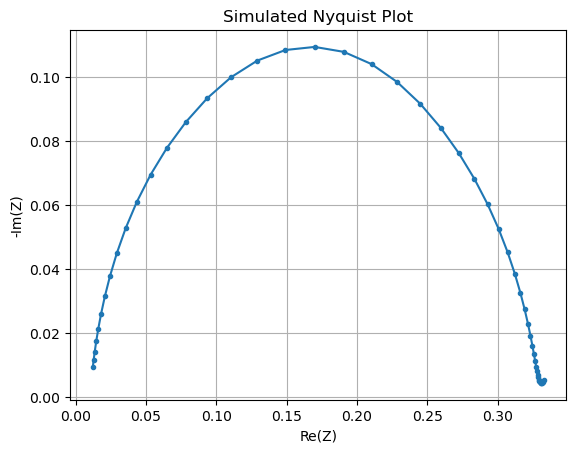

In [121]:
# Note: We have exact freqency data (50 points) for each original SOH-SOC for each cell. They are all different
# but all within 0.1 Hz to 10k Hz. We sample **new 50 points** of frequency points to compare.
omega = np.logspace(-1, 4, 50) * 2*np.pi  # 0.1 Hz to 10k Hz -> rad/s

example_params = df_theta_sim_ind.iloc[0]
Z_example = ecm_impedance_C9(example_params, omega)

plt.figure()
plt.plot(Z_example.real, -Z_example.imag, marker='.')
plt.xlabel('Re(Z)')
plt.ylabel('-Im(Z)')
plt.title('Simulated Nyquist Plot')
plt.grid(True)
plt.show()

Each SOH bin, plot original and simulation data:

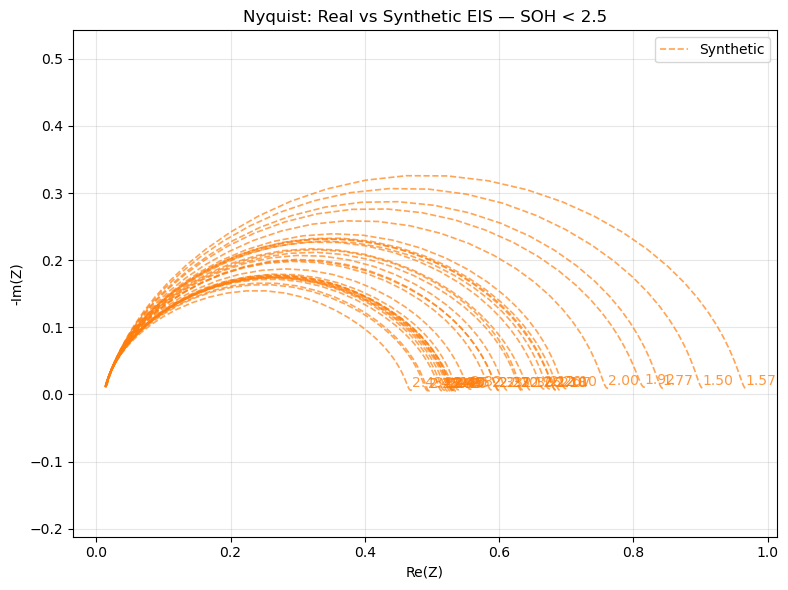

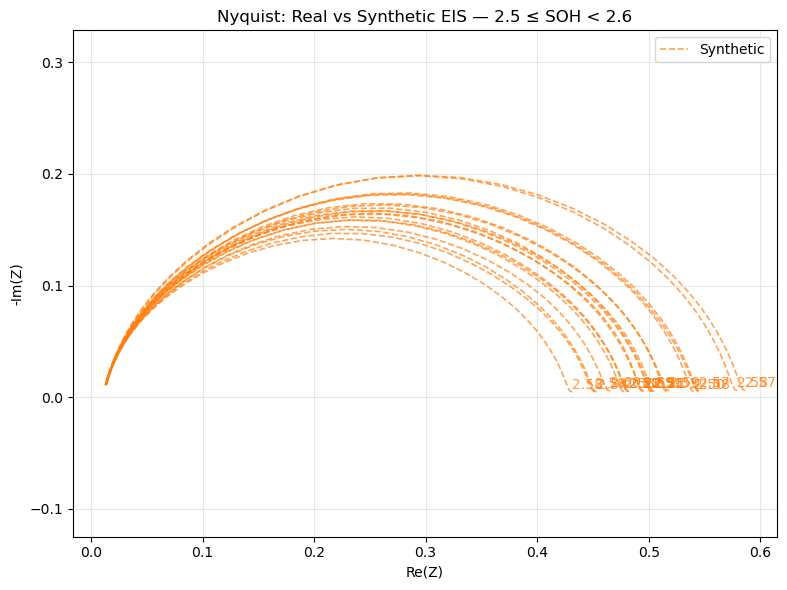

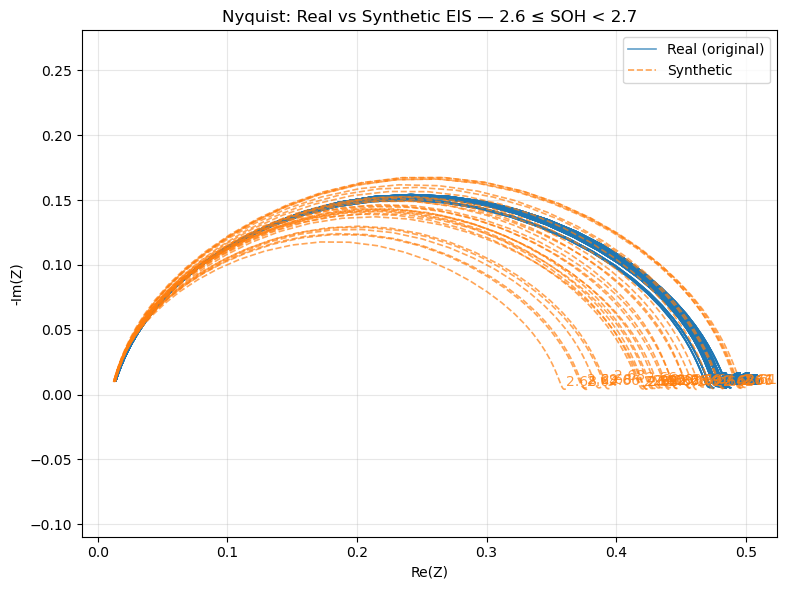

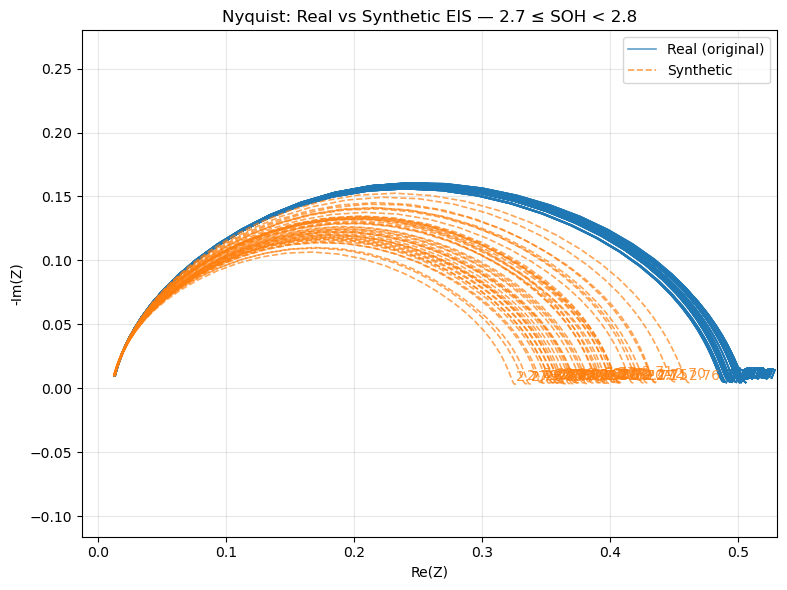

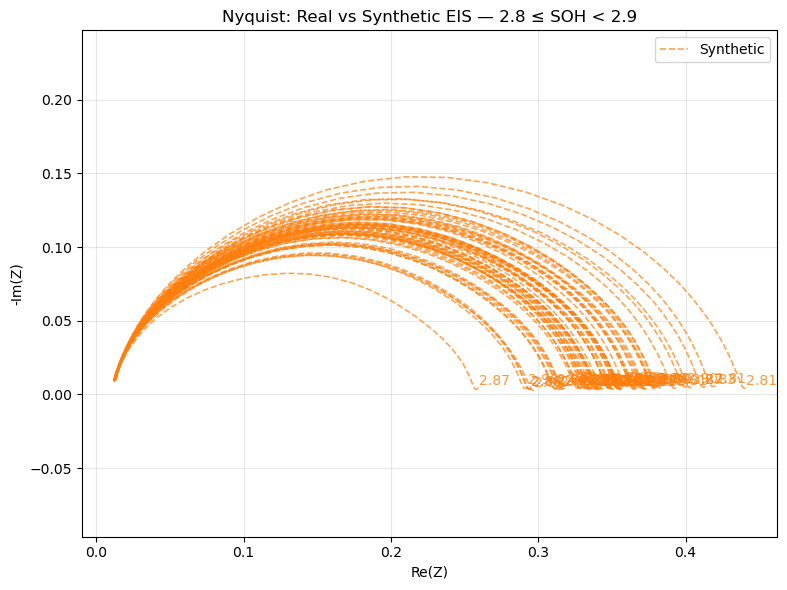

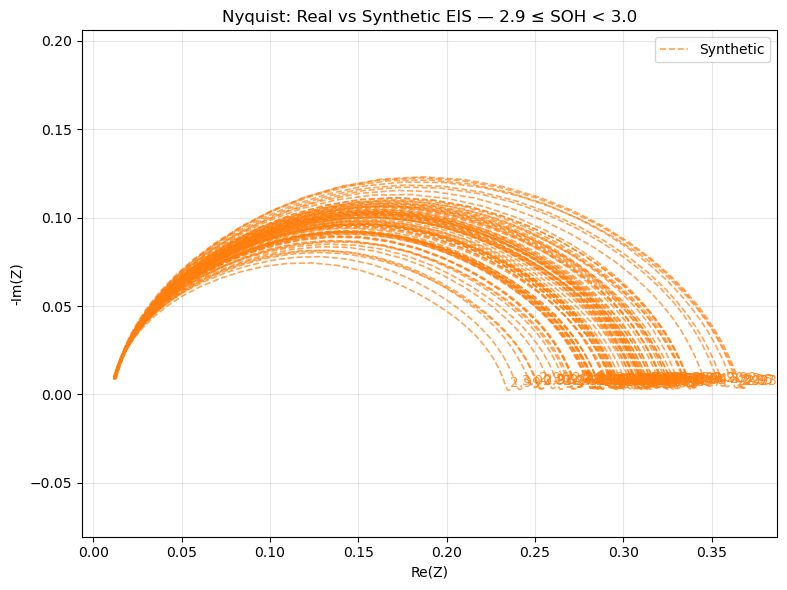

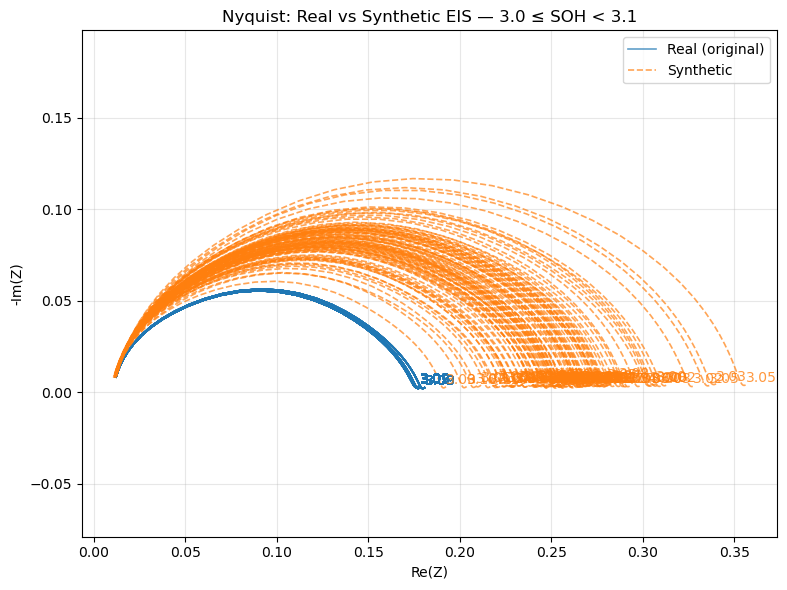

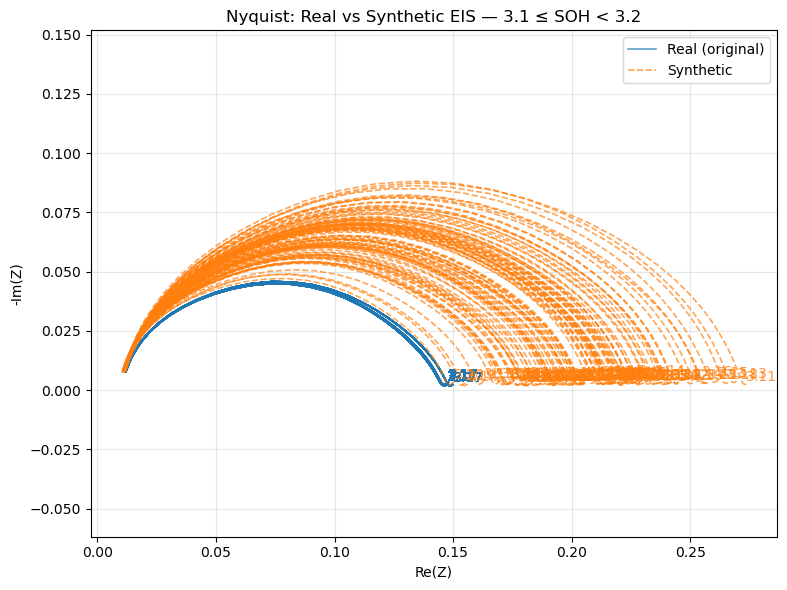

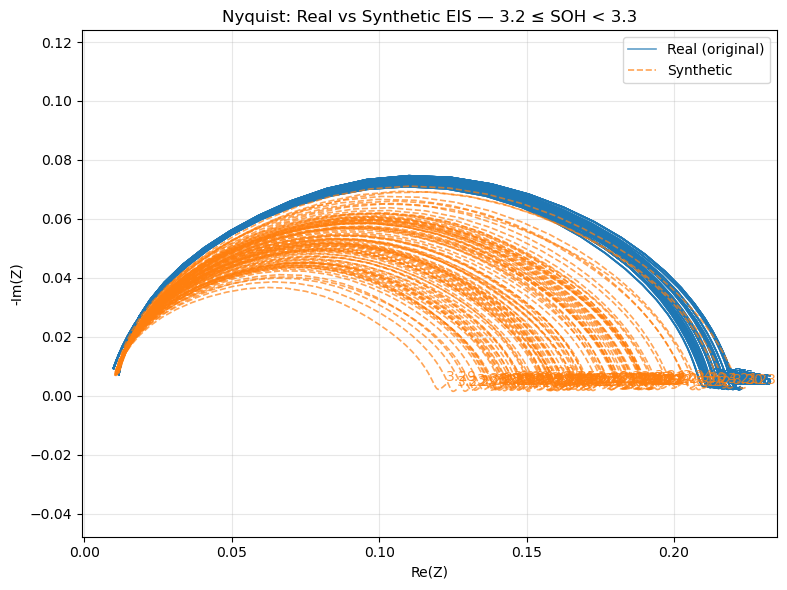

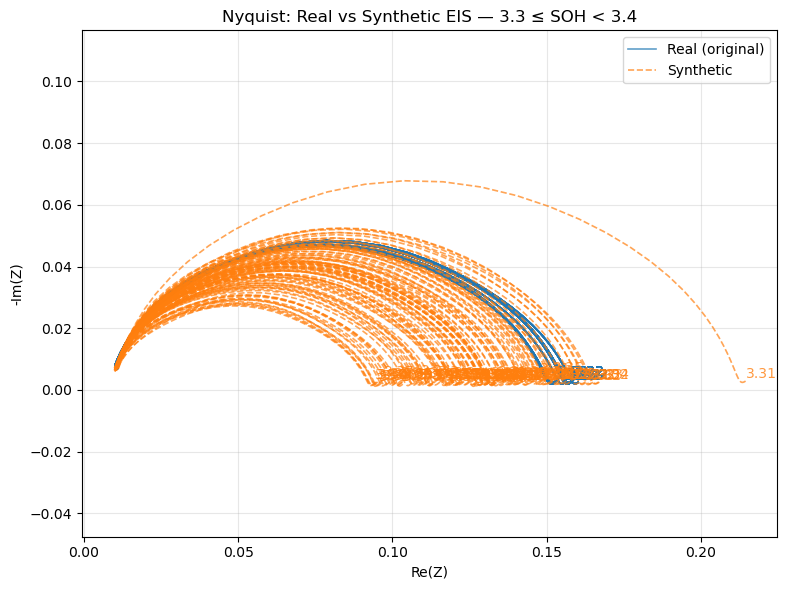

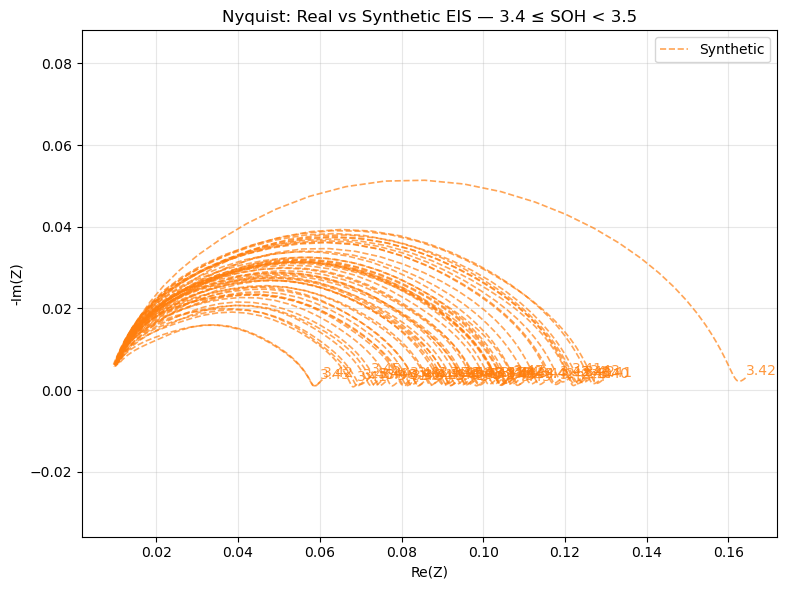

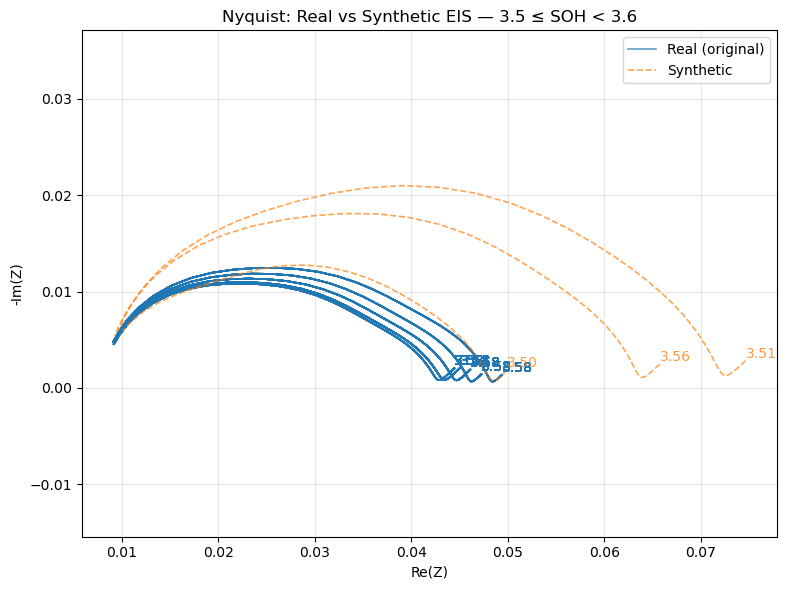

In [174]:
# Frequency grid: 0.1 Hz to 100 kHz (in rad/s)
omega = np.logspace(-1, 4, 50) * 2 * np.pi


# ===  Define SOH bins: SOH < 2.5, then [2.5,2.6), [2.6,2.7), ..., [3.5,3.6) ===
bin_edges = [2.5] + list(np.arange(2.5, 3.6, 0.1))  
# We'll treat specially the first bin SOH < 2.5
# and then (2.5 <= SOH < 2.6), (2.6 <= SOH < 2.7), ..., (3.5 <= SOH < 3.6)

soh_bins = []
soh_bin_labels = []

# First bin: SOH < 2.5
soh_bins.append((-np.inf, 2.5))
soh_bin_labels.append("SOH < 2.5")

# Remaining bins: [2.8,2.9), [2.9,3.0), ..., [3.5,3.6)
for low in np.arange(2.5, 3.6, 0.1):
    high = low + 0.1
    soh_bins.append((low, high))
    soh_bin_labels.append(f"{low:.1f} ≤ SOH < {high:.1f}")


def annotate_soh_on_curve(ax, Z, soh_value, color, fontsize=10):
    """
    Annotate SOH near the Nyquist curve.
    Places text at the point with max real(Z).
    """
    re_z = Z.real
    im_z = -Z.imag  # we plot -Im(Z)
    idx = np.argmax(re_z)
    ax.text(
        re_z[idx], im_z[idx],
        f"{soh_value:.2f}",
        color=color,
        fontsize=fontsize,
        ha='left',
        va='bottom',
        alpha=0.8
    )

# === Plot per SOH bin ===
# Colors for real vs synthetic
color_real = "tab:blue"
color_synth = "tab:orange"

rng_plot = np.random.default_rng(42)  

for (low, high), bin_label in zip(soh_bins, soh_bin_labels):
    # ------------------------------------------------------
    # 1. Select original (real) samples in this SOH bin
    # ------------------------------------------------------
    if np.isneginf(low):
        mask_real = (df_dind['SOH'] < high)
    else:
        mask_real = (df_dind['SOH'] >= low) & (df_dind['SOH'] < high)
    
    df_bin_real = df_dind[mask_real]
    
    # ------------------------------------------------------
    # 2. Select synthetic samples in this SOH bin
    #    using SOH_sim from synthetic dataframe
    # ------------------------------------------------------
    if np.isneginf(low):
        mask_synth = (df_theta_sim_ind['SOH_sim'] < high)
    else:
        mask_synth = (df_theta_sim_ind['SOH_sim'] >= low) & (df_theta_sim_ind['SOH_sim'] < high)
    
    df_bin_synth = df_theta_sim_ind[mask_synth]
    
    # Skip bin if no data at all
    if len(df_bin_real) == 0 and len(df_bin_synth) == 0:
        continue
    
    # Sample up to 10 from each (without replacement)
    n_real = min(100, len(df_bin_real))
    n_synth = min(100, len(df_bin_synth))
    
    df_real_sample = df_bin_real.sample(n=n_real, random_state=rng_plot.integers(0, 10_000)) if n_real > 0 else pd.DataFrame(columns=df_dind.columns)
    df_synth_sample = df_bin_synth.sample(n=n_synth, random_state=rng_plot.integers(0, 10_000)) if n_synth > 0 else pd.DataFrame(columns=df_theta_sim_ind.columns)
    
    # ------------------------------------------------------
    # 3. Plot Nyquist curves: real vs synthetic
    # ------------------------------------------------------
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # --- Real curves ---
    first_real = True
    for _, row in df_real_sample.iterrows():
        params = row  # contains R0..R3,Q1..Q3,n1..n3,Aw,SOH
        Z = ecm_impedance_C9(params, omega)
        ax.plot(Z.real, -Z.imag,
                color=color_real,
                alpha=0.7,
                linewidth=1.2,
                label="Real (original)" if first_real else None)
        annotate_soh_on_curve(ax, Z, row['SOH'], color_real)
        first_real = False
    
    # --- Synthetic curves ---
    first_synth = True
    for _, row in df_synth_sample.iterrows():
        params = row  # contains R0..R3,Q1..Q3,n1..n3,Aw,SOH_sim
        Z = ecm_impedance_C9(params, omega)
        ax.plot(Z.real, -Z.imag,
                color=color_synth,
                alpha=0.7,
                linewidth=1.2,
                linestyle='--',
                label="Synthetic" if first_synth else None)
        annotate_soh_on_curve(ax, Z, row['SOH_sim'], color_synth)
        first_synth = False
    
    ax.set_xlabel(r"Re(Z)")
    ax.set_ylabel(r"-Im(Z)")
    ax.set_title(f"Nyquist: Real vs Synthetic EIS — {bin_label}")
    ax.grid(alpha=0.3)
    ax.legend(loc="best")
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

per-cell

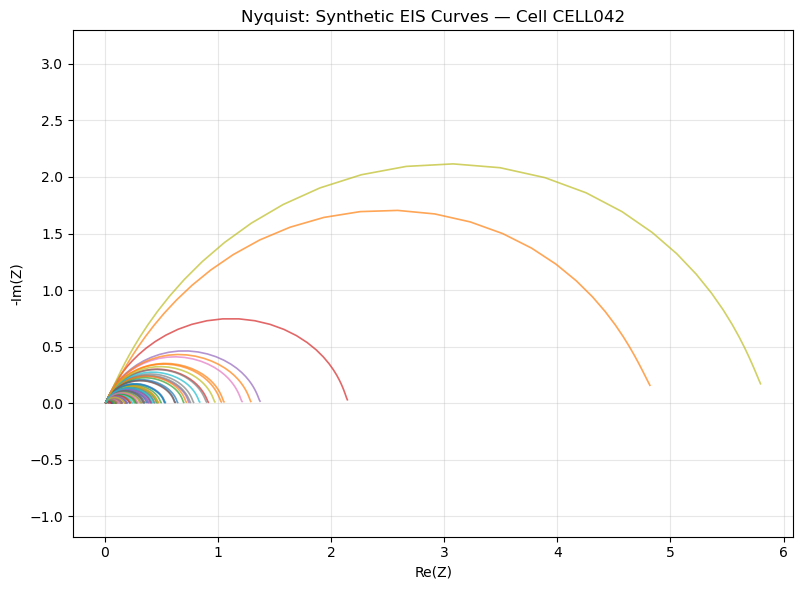

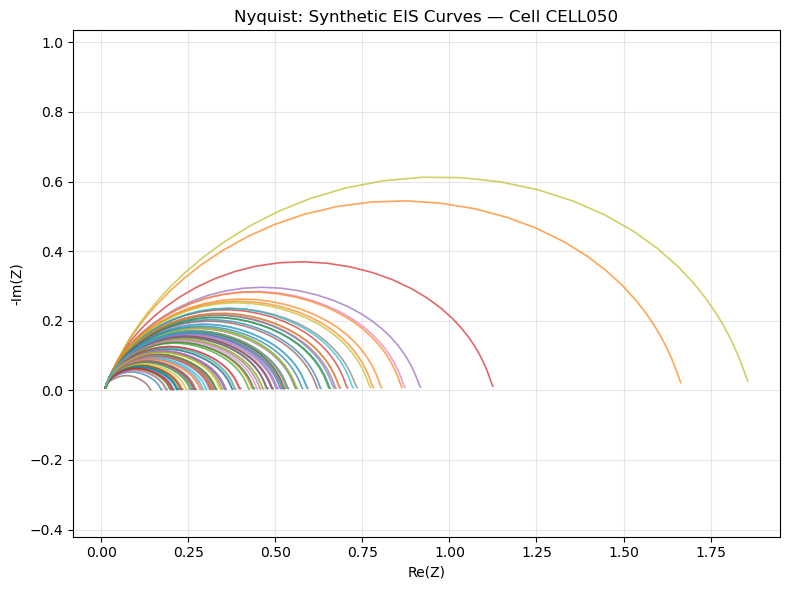

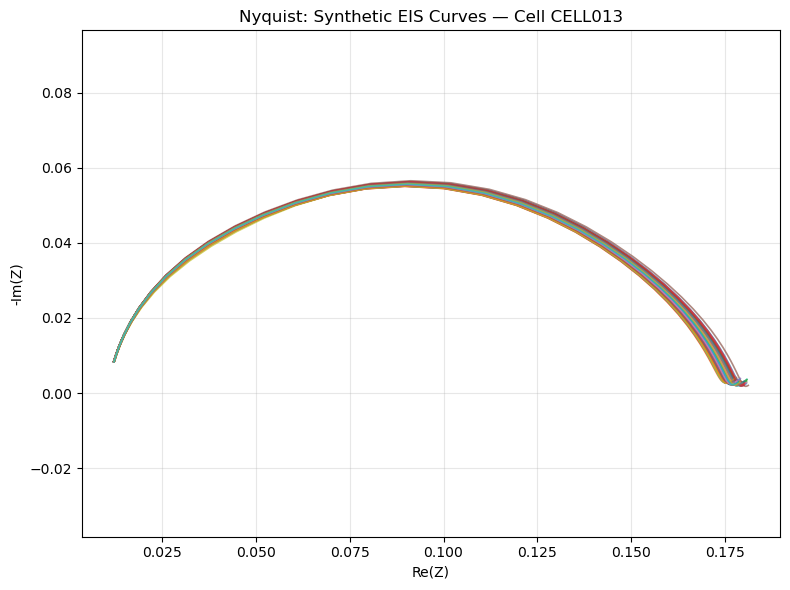

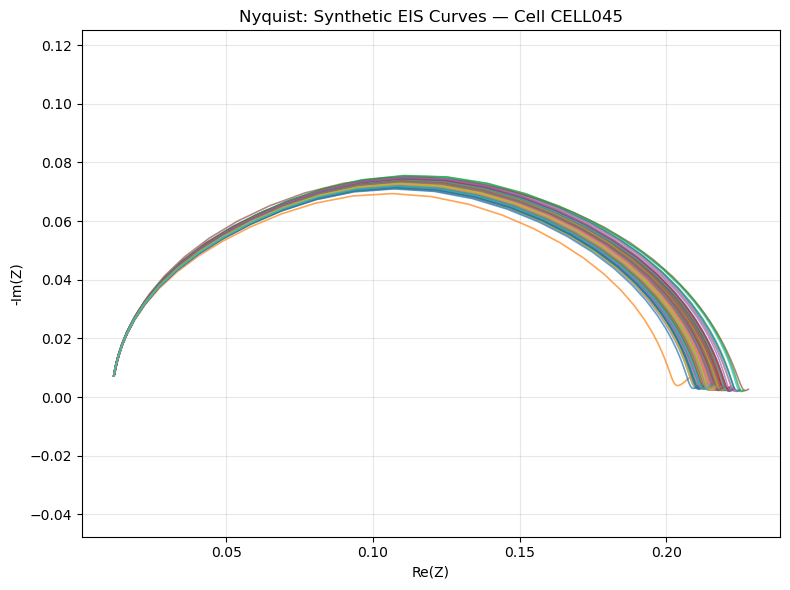

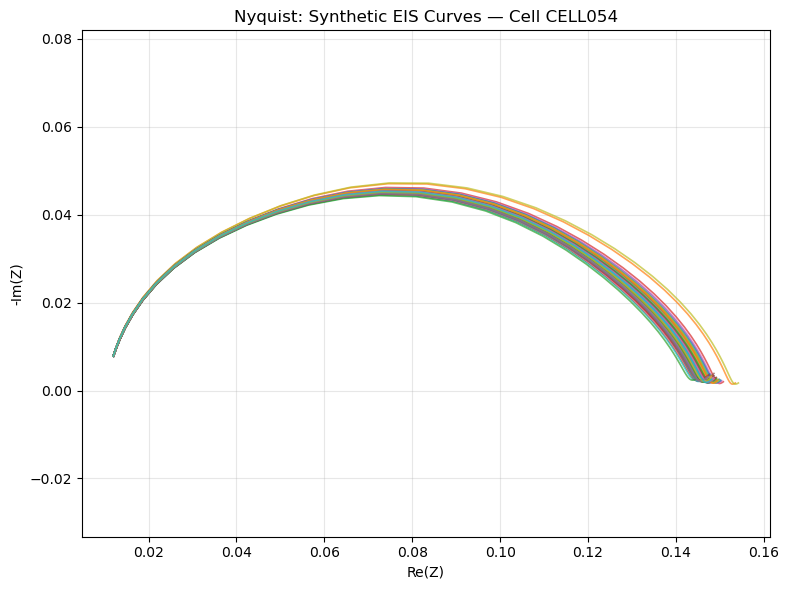

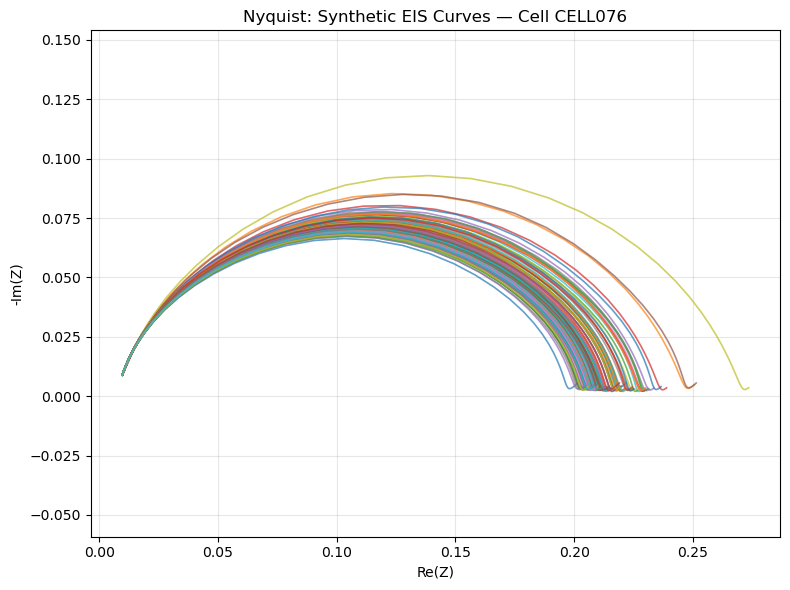

In [158]:
cells = list(mean_dict_dind.keys())
for cell in cells:
    # Reconstruct EIS curves for synthetic samples of this cell
    df_cell = per_cell_sim_ind[cell]
    fig, ax = plt.subplots(figsize=(8, 6))
    for _, row in df_cell.iterrows():
        params = row  # contains R0..R3,Q1..Q3,n1..n3,Aw,SOH_sim
        Z = ecm_impedance_C9(params, omega)
        ax.plot(Z.real, -Z.imag,
                alpha=0.7,
                linewidth=1.2)
        # annotate_soh_on_curve(ax, Z, row['SOH_sim'], color='tab:orange')
    
    # original curves for this cell
    # df_cell_real = df_dind[df_dind['CELL'] == cell]
    # for _, row in df_cell_real.iterrows():
    #     params = row  # contains R0..R3,Q1..Q3,n1..n3,Aw,SOH
    #     Z = ecm_impedance_C9(params, omega)
    #     ax.plot(Z.real, -Z.imag,
    #             color='tab:blue',
    #             alpha=0.5,
    #             linewidth=2.2)
    #     # annotate_soh_on_curve(ax, Z, row['SOH'], color='tab:blue')

    ax.set_xlabel(r"Re(Z)")
    ax.set_ylabel(r"-Im(Z)")
    ax.set_title(f"Nyquist: Synthetic EIS Curves — Cell {cell}")
    ax.grid(alpha=0.3)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()
